# Recent Dataset — Training-Only EDA using Final Project B Features

This notebook treats `final_feature_B.txt` as the predefined feature inventory for the benchmark models. Feature analysis is limited to sanity checks and descriptive diagnostics; it does not repeat Project B's feature-selection process.


## 1. Imports and global configuration

In [1]:
import json
import re
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# -----------------------------
# Canonical column names
# -----------------------------
INDEX_COL = "IndexReference"
DATE_COL = "attr__timestamp"
TICKER_COL = "attr__ticker"
SIC2_COL = "attr__sic2"
YEAR_COL = "year"
SPLIT_COL = "split"

# -----------------------------
# Dataset configuration
# -----------------------------
PROJECT_ROOT = Path.cwd()

UNIVERSE = "universe_100"
TIME_HORIZON = "recent"
NORMALISATION_STATUS = "post_normalisation"

DATASET_NAME = f"{UNIVERSE}_{TIME_HORIZON}_{NORMALISATION_STATUS}"

# Change this path if the training file is stored elsewhere.
TRAIN_PATH = PROJECT_ROOT / f"{DATASET_NAME}_train.jsonl"

# Optional Project B feature inventory.
PROJECT_B_FEATURE_FILE = PROJECT_ROOT / "final_feature_B.txt"

# -----------------------------
# EDA configuration
# -----------------------------
MISSING_THRESHOLD = 0.50
CORR_THRESHOLD = 0.95
TOP_MISSING_FEATURES_TO_PLOT = 30
TOP_VARIABLE_FEATURES_TO_PLOT = 20
TOP_CORRELATION_FEATURES = 30
HISTOGRAM_BINS = 50
FIGURE_DPI = 180

# Set to None to analyse every available derived/raw target.
SELECTED_TARGETS = None

# -----------------------------
# Output folders
# -----------------------------
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = PROJECT_ROOT / f"recent_training_eda_outputs_{RUN_TIMESTAMP}"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
INVENTORY_DIR = OUTPUT_DIR / "inventories"

for folder in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, INVENTORY_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATASET_NAME)
print("Training path:", TRAIN_PATH)
print("Training file exists:", TRAIN_PATH.exists())
print("Output directory:", OUTPUT_DIR.resolve())


Dataset: universe_100_recent_post_normalisation
Training path: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\universe_100_recent_post_normalisation_train.jsonl
Training file exists: True
Output directory: C:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547


## 2. Reusable export helpers

In [18]:
EXPORTED_TABLES = {}


def safe_name(value, max_len=140):
    value = re.sub(r"[^A-Za-z0-9_\-]+", "_", str(value))
    value = re.sub(r"_+", "_", value).strip("_")
    return (value or "output")[:max_len]

def make_excel_safe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col in df.columns:
        # Handles normal datetime64 columns
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            try:
                df[col] = df[col].dt.tz_localize(None)
            except TypeError:
                # Already timezone-naive
                pass

        # Handles object columns containing timezone-aware Timestamp values
        elif df[col].dtype == "object":
            if df[col].map(lambda x: isinstance(x, pd.Timestamp)).any():
                df[col] = df[col].map(
                    lambda x: x.tz_localize(None)
                    if isinstance(x, pd.Timestamp) and x.tzinfo is not None
                    else x
                )

    return df

def export_table(name, df, display_table=True):
    """Register and export a DataFrame as CSV and XLSX."""
    if df is None:
        return None

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    key = safe_name(name)
    EXPORTED_TABLES[key] = df.copy()

    csv_path = TABLE_DIR / f"{key}.csv"
    xlsx_path = TABLE_DIR / f"{key}.xlsx"

    df.to_csv(csv_path, index=False)
    try:
        excel_df = make_excel_safe(df)
        excel_df.to_excel(xlsx_path, index=False)
    except Exception as exc:
        print(f"Excel export skipped for {key}: {exc}")

    if display_table:
        display(df)

    print(f"Saved table: {csv_path}")
    return df


def save_current_figure(name, close=False):
    """Save the current matplotlib figure with a consistent filename."""
    path = FIGURE_DIR / f"{safe_name(name)}.png"
    plt.tight_layout()
    plt.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
    print(f"Saved figure: {path}")

    if close:
        plt.close()

    return path


def export_all_tables_to_workbook(
    filename="recent_training_eda_all_tables.xlsx"
):
    workbook_path = TABLE_DIR / filename
    used_sheets = set()

    with pd.ExcelWriter(workbook_path, engine="openpyxl") as writer:
        if not EXPORTED_TABLES:
            pd.DataFrame({
                "message": ["No tables have been registered."]
            }).to_excel(
                writer,
                sheet_name="README",
                index=False
            )

        else:
            for name, df in EXPORTED_TABLES.items():
                sheet = safe_name(name, max_len=31)
                base = sheet
                counter = 1

                # Ensure every sheet name is unique
                while sheet in used_sheets:
                    suffix = f"_{counter}"
                    sheet = safe_name(
                        base[:31 - len(suffix)] + suffix,
                        max_len=31
                    )
                    counter += 1

                used_sheets.add(sheet)

                # Remove timezone information before Excel export
                excel_df = make_excel_safe(df)

                excel_df.head(1_000_000).to_excel(
                    writer,
                    sheet_name=sheet,
                    index=False
                )

    print("Saved integrated workbook:", workbook_path.resolve())
    return workbook_path



## 3. Dataset loading and standardisation

In [19]:
def load_flatten_jsonl(path):
    """Load and flatten Adaptive Swarm model-ready JSONL data."""
    rows = []
    path = Path(path)

    def open_text_file(file_path):
        if file_path.suffix.lower() == ".gz":
            import gzip
            return gzip.open(file_path, "rt", encoding="utf-8")
        return file_path.open("r", encoding="utf-8")

    with open_text_file(path) as file:
        for line in file:
            if not line.strip():
                continue

            raw_record = json.loads(line)

            if raw_record.get("section") == "header":
                continue

            record = (
                raw_record.get("data", {}) or {}
                if raw_record.get("section") == "data"
                else raw_record
            )

            if not isinstance(record, dict):
                continue

            attributes = (
                record.get("Attributes")
                or record.get("attributes")
                or record.get("attrs")
                or {}
            )
            features = record.get("Features") or record.get("features") or {}
            labels = record.get("Labels") or record.get("labels") or {}

            row = {
                INDEX_COL: record.get(
                    "IndexReference",
                    raw_record.get("IndexReference")
                )
            }

            for key, value in attributes.items():
                column = key if str(key).startswith("attr__") else f"attr__{key}"
                row[column] = value

            for key, value in features.items():
                column = key if str(key).startswith("feature__") else f"feature__{key}"
                row[column] = value

            for key, value in labels.items():
                column = key if str(key).startswith("label__") else f"label__{key}"
                row[column] = value

            # Preserve scalar fields for auditability.
            excluded = {
                "Attributes", "attributes", "attrs",
                "Features", "features",
                "Labels", "labels"
            }
            for key, value in record.items():
                if key not in excluded and not isinstance(value, (dict, list)):
                    row.setdefault(key, value)

            rows.append(row)

    df = pd.DataFrame(rows)
    print("Flattened JSONL shape:", df.shape)
    return df


def load_jsonl_zip(path):
    """Load a zip archive containing one JSONL file."""
    import zipfile

    path = Path(path)
    rows = []

    with zipfile.ZipFile(path, "r") as archive:
        jsonl_files = [
            name for name in archive.namelist()
            if name.lower().endswith(".jsonl")
        ]

        if not jsonl_files:
            raise ValueError(f"No JSONL file found inside: {path}")

        with archive.open(jsonl_files[0], "r") as file:
            for raw_line in file:
                line = raw_line.decode("utf-8")
                if not line.strip():
                    continue

                raw_record = json.loads(line)
                if raw_record.get("section") == "header":
                    continue

                record = (
                    raw_record.get("data", {}) or {}
                    if raw_record.get("section") == "data"
                    else raw_record
                )

                if not isinstance(record, dict):
                    continue

                attributes = (
                    record.get("Attributes")
                    or record.get("attributes")
                    or record.get("attrs")
                    or {}
                )
                features = record.get("Features") or record.get("features") or {}
                labels = record.get("Labels") or record.get("labels") or {}

                row = {
                    INDEX_COL: record.get(
                        "IndexReference",
                        raw_record.get("IndexReference")
                    )
                }

                for key, value in attributes.items():
                    column = key if str(key).startswith("attr__") else f"attr__{key}"
                    row[column] = value

                for key, value in features.items():
                    column = key if str(key).startswith("feature__") else f"feature__{key}"
                    row[column] = value

                for key, value in labels.items():
                    column = key if str(key).startswith("label__") else f"label__{key}"
                    row[column] = value

                rows.append(row)

    df = pd.DataFrame(rows)
    print("Flattened zipped JSONL shape:", df.shape)
    return df


def load_table(path):
    """Load parquet, CSV, JSON, JSONL, compressed JSONL, or zipped JSONL."""
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    filename = path.name.lower()
    suffix = path.suffix.lower()

    if suffix == ".parquet":
        return pd.read_parquet(path)

    if suffix == ".csv":
        return pd.read_csv(path)

    if suffix == ".jsonl" or filename.endswith(".jsonl.gz"):
        return load_flatten_jsonl(path)

    if filename.endswith(".jsonl.zip"):
        return load_jsonl_zip(path)

    if suffix == ".json":
        try:
            return pd.read_json(path, lines=True)
        except ValueError:
            return pd.read_json(path)

    raise ValueError(f"Unsupported file format: {path}")


def standardise_frame(df, split_name="train"):
    """Apply canonical date, ticker, SIC, year, and split variables."""
    df = df.copy()
    df[SPLIT_COL] = split_name

    if INDEX_COL not in df.columns:
        df[INDEX_COL] = np.arange(len(df))
        print(f"Warning: generated fallback {INDEX_COL} values.")

    if DATE_COL in df.columns:
        df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
        df[YEAR_COL] = df[DATE_COL].dt.year
    else:
        df[YEAR_COL] = np.nan
        print(f"Warning: {DATE_COL} is absent.")

    for column in [TICKER_COL, SIC2_COL]:
        if column not in df.columns:
            df[column] = np.nan

    return df


df_train = standardise_frame(load_table(TRAIN_PATH), split_name="train")

print("Training shape:", df_train.shape)
print("Date range:", df_train[DATE_COL].min(), "to", df_train[DATE_COL].max())
print("Number of tickers:", df_train[TICKER_COL].nunique(dropna=True))


Flattened JSONL shape: (98419, 747)
Training shape: (98419, 749)
Date range: 2020-01-02 00:00:00+00:00 to 2023-12-29 00:00:00+00:00
Number of tickers: 98


## 4. Canonical column inventories

In [20]:
attribute_cols = sorted([c for c in df_train.columns if c.startswith("attr__")])
feature_cols = sorted([c for c in df_train.columns if c.startswith("feature__")])
label_cols = sorted([c for c in df_train.columns if c.startswith("label__")])

inventory_summary = pd.DataFrame({
    "column_family": ["attributes", "features", "labels", "other"],
    "n_columns": [
        len(attribute_cols),
        len(feature_cols),
        len(label_cols),
        len(df_train.columns) - len(attribute_cols) - len(feature_cols) - len(label_cols)
    ]
})

export_table("column_family_summary", inventory_summary)

for filename, columns in {
    "attribute_columns.txt": attribute_cols,
    "feature_columns.txt": feature_cols,
    "label_columns.txt": label_cols
}.items():
    path = INVENTORY_DIR / filename
    path.write_text("\n".join(columns), encoding="utf-8")
    print("Saved inventory:", path)

print("Attributes:", len(attribute_cols))
print("Features:", len(feature_cols))
print("Labels:", len(label_cols))


,column_family,n_columns
0,attributes,46
1,features,621
2,labels,78
3,other,4


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\tables\column_family_summary.csv
Saved inventory: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\inventories\attribute_columns.txt
Saved inventory: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\inventories\feature_columns.txt
Saved inventory: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\inventories\label_columns.txt
Attributes: 46
Features: 621
Labels: 78


## 5. Derived target construction

In [21]:
def first_existing_column(df, candidates):
    for column in candidates:
        if column in df.columns:
            return column
    return None


def make_pi_hindsight_entry_long_6bins(series):
    values = pd.to_numeric(series, errors="coerce")
    output = pd.Series(np.nan, index=values.index)

    output[values == 0] = 0
    output[(values > 0) & (values < 0.1)] = 1
    output[(values >= 0.1) & (values < 0.2)] = 2
    output[(values >= 0.2) & (values < 0.3)] = 3
    output[(values >= 0.3) & (values < 0.4)] = 4
    output[values >= 0.4] = 5

    return output.astype("Int64")


def add_derived_targets(df):
    df = df.copy()

    pi_column = first_existing_column(
        df,
        [
            "label__pi_hindsight_entry_long",
            "label__pi_long_entry",
            "pi_hindsight_entry_long"
        ]
    )

    if pi_column is not None:
        df["target__pi_hindsight_entry_long"] = pd.to_numeric(
            df[pi_column], errors="coerce"
        )
        df["target__pi_hindsight_entry_positive"] = (
            df["target__pi_hindsight_entry_long"] > 0
        ).astype("Int64")
        df["target__pi_hindsight_entry_original"] = (
            df["target__pi_hindsight_entry_long"] >= 0.4
        ).astype("Int64")
        df["target__pi_hindsight_entry_6bins"] = (
            make_pi_hindsight_entry_long_6bins(
                df["target__pi_hindsight_entry_long"]
            )
        )

    target_source_map = {
        "target__rl_long_is_best": [
            "label__rl.long_is_best",
            "label__rl_long_is_best"
        ],
        "target__rl_long_action_quality": [
            "label__rl.long.action_quality",
            "label__rl_long_action_quality"
        ],
        "target__rl_long_action_binary": [
            "label__rl.long.action_label",
            "label__rl_long_action_binary"
        ],
        "target__rl_long_reward": [
            "label__rl.reward.long",
            "label__rl_reward_long",
            "label__rl.long.reward"
        ],
        "target__rl_long_current_pnl": [
            "label__rl.long.current_pnl",
            "label__rl_long_current_pnl",
            "label__rl.long_current_pnl",
            "label__current_pnl"
        ]
    }

    for target_column, candidates in target_source_map.items():
        source_column = first_existing_column(df, candidates)
        if source_column is not None:
            df[target_column] = pd.to_numeric(
                df[source_column], errors="coerce"
            )

    return df


df_train = add_derived_targets(df_train)
target_cols = sorted([c for c in df_train.columns if c.startswith("target__")])

print("Available derived targets:")
for column in target_cols:
    print(" -", column)

pd.Series(target_cols).to_csv(
    INVENTORY_DIR / "derived_target_columns.txt",
    index=False,
    header=False
)


Available derived targets:
 - target__pi_hindsight_entry_6bins
 - target__pi_hindsight_entry_long
 - target__pi_hindsight_entry_original
 - target__pi_hindsight_entry_positive
 - target__rl_long_action_binary
 - target__rl_long_action_quality
 - target__rl_long_current_pnl
 - target__rl_long_reward


## 6. Dataset coverage and structural checks

In [22]:
dataset_overview = pd.DataFrame([{
    "dataset_name": DATASET_NAME,
    "n_rows": len(df_train),
    "n_columns": df_train.shape[1],
    "n_attributes": len(attribute_cols),
    "n_features": len(feature_cols),
    "n_raw_labels": len(label_cols),
    "n_derived_targets": len(target_cols),
    "n_tickers": df_train[TICKER_COL].nunique(dropna=True),
    "start_date": df_train[DATE_COL].min(),
    "end_date": df_train[DATE_COL].max(),
    "duplicate_index_references": df_train[INDEX_COL].duplicated().sum(),
    "missing_index_reference_rate": df_train[INDEX_COL].isna().mean(),
    "missing_timestamp_rate": df_train[DATE_COL].isna().mean(),
    "missing_ticker_rate": df_train[TICKER_COL].isna().mean()
}])

export_table("dataset_overview", dataset_overview)

ticker_coverage = (
    df_train.groupby(TICKER_COL, dropna=False)
    .agg(
        n_rows=(INDEX_COL, "size"),
        start_date=(DATE_COL, "min"),
        end_date=(DATE_COL, "max"),
        n_years=(YEAR_COL, "nunique")
    )
    .reset_index()
    .sort_values("n_rows", ascending=False)
)

export_table("ticker_coverage", ticker_coverage)

year_coverage = (
    df_train.groupby(YEAR_COL, dropna=False)
    .agg(
        n_rows=(INDEX_COL, "size"),
        n_tickers=(TICKER_COL, "nunique")
    )
    .reset_index()
    .sort_values(YEAR_COL)
)

export_table("year_coverage", year_coverage)

ticker_year_coverage = (
    df_train.groupby([TICKER_COL, YEAR_COL], dropna=False)
    .size()
    .rename("n_rows")
    .reset_index()
)

export_table("ticker_year_coverage", ticker_year_coverage)


,dataset_name,n_rows,n_columns,n_attributes,n_features,n_raw_labels,n_derived_targets,n_tickers,start_date,end_date,duplicate_index_references,missing_index_reference_rate,missing_timestamp_rate,missing_ticker_rate
0,universe_100_recent_post_normalisation,98419,757,46,621,78,8,98,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,0,0.0,0.0,0.0


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\tables\dataset_overview.csv


,attr__ticker,n_rows,start_date,end_date,n_years
0,AAPL,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
1,ABBV,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
2,ABT,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
3,ACN,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
4,ADBE,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
...,...,...,...,...,...
94,VZ,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
97,XOM,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
95,WFC,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
92,UNP,981,2020-01-02 00:00:00+00:00,2023-11-22 00:00:00+00:00,4


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\tables\ticker_coverage.csv


,year,n_rows,n_tickers
0,2020,24650,98
1,2021,24696,98
2,2022,24598,98
3,2023,24475,98


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\tables\year_coverage.csv


,attr__ticker,year,n_rows
0,AAPL,2020,253
1,AAPL,2021,252
2,AAPL,2022,251
3,AAPL,2023,250
4,ABBV,2020,253
...,...,...,...
387,WMT,2023,250
388,XOM,2020,253
389,XOM,2021,252
390,XOM,2022,251


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\tables\ticker_year_coverage.csv


,attr__ticker,year,n_rows
0,AAPL,2020,253
1,AAPL,2021,252
2,AAPL,2022,251
3,AAPL,2023,250
4,ABBV,2020,253
...,...,...,...
387,WMT,2023,250
388,XOM,2020,253
389,XOM,2021,252
390,XOM,2022,251


Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\training_observations_by_ticker.png


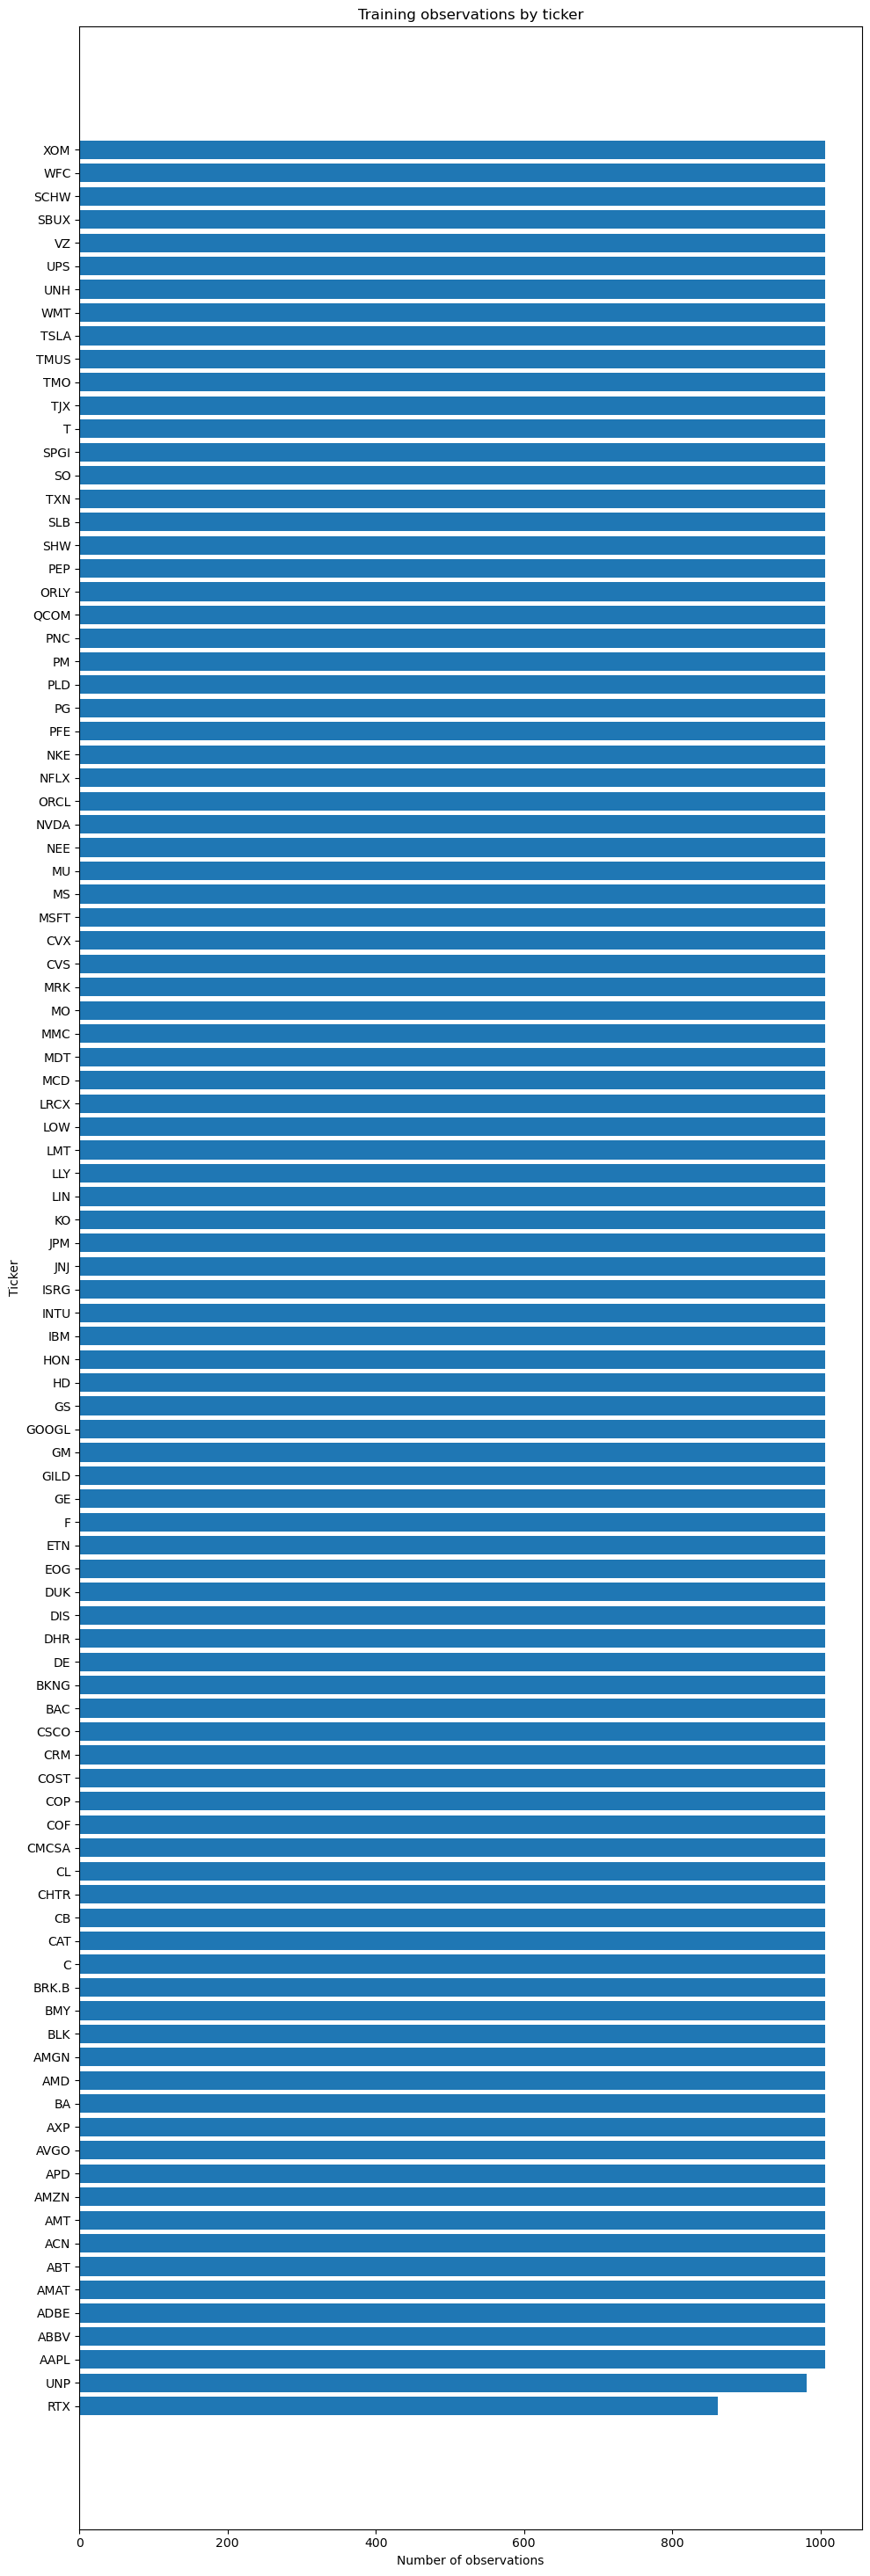

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\training_observations_by_year.png


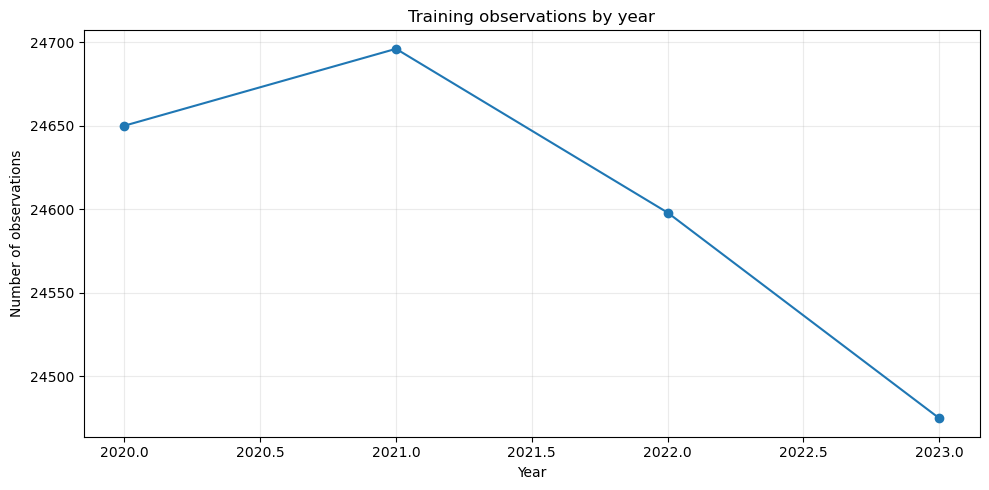

In [23]:
# Observations by ticker
plot_data = ticker_coverage.dropna(subset=[TICKER_COL]).sort_values("n_rows")

plt.figure(figsize=(10, max(5, 0.3 * len(plot_data))))
plt.barh(plot_data[TICKER_COL].astype(str), plot_data["n_rows"])
plt.title("Training observations by ticker")
plt.xlabel("Number of observations")
plt.ylabel("Ticker")
save_current_figure("training_observations_by_ticker")
plt.show()

# Observations by year
year_plot = year_coverage.dropna(subset=[YEAR_COL])

plt.figure(figsize=(10, 5))
plt.plot(year_plot[YEAR_COL], year_plot["n_rows"], marker="o")
plt.title("Training observations by year")
plt.xlabel("Year")
plt.ylabel("Number of observations")
plt.grid(alpha=0.25)
save_current_figure("training_observations_by_year")
plt.show()


## 7. Final Project B feature-set sanity checks

The Project B feature list is treated as the predefined modelling input. The following checks assess availability, missingness, degeneracy, invalid values, distribution shape, temporal/ticker coverage and residual correlation. They are quality-assurance diagnostics only and do not constitute a new feature-selection stage.


In [24]:
def normalise_feature_name(feature):
    """Match the unprefixed Project B inventory to flattened dataset columns."""
    feature = str(feature).strip()
    return feature if feature.startswith("feature__") else f"feature__{feature}"


if not PROJECT_B_FEATURE_FILE.exists():
    raise FileNotFoundError(
        f"Final Project B feature list was not found: {PROJECT_B_FEATURE_FILE}"
    )

raw_final_feature_b = [
    line.strip()
    for line in PROJECT_B_FEATURE_FILE.read_text(encoding="utf-8").splitlines()
    if line.strip()
]

final_feature_b_requested = [
    normalise_feature_name(feature)
    for feature in raw_final_feature_b
]

# Preserve the file order while removing accidental duplicates.
final_feature_b_requested = list(dict.fromkeys(final_feature_b_requested))

final_feature_b_available = [
    feature for feature in final_feature_b_requested
    if feature in df_train.columns
]

final_feature_b_missing = [
    feature for feature in final_feature_b_requested
    if feature not in df_train.columns
]

print("Features requested by final_feature_B:", len(final_feature_b_requested))
print("Available in training data:", len(final_feature_b_available))
print("Missing from training data:", len(final_feature_b_missing))

if final_feature_b_missing:
    display(pd.DataFrame({"missing_feature": final_feature_b_missing}))


def numeric_column_summary(data, columns):
    rows = []

    for column in columns:
        raw = data[column]
        values = pd.to_numeric(raw, errors="coerce")
        finite_mask = np.isfinite(values)

        rows.append({
            "column": column,
            "dtype": str(raw.dtype),
            "n_rows": len(raw),
            "count_numeric": int(values.notna().sum()),
            "missing_count": int(values.isna().sum()),
            "missing_rate": float(values.isna().mean()),
            "non_finite_count": int((values.notna() & ~finite_mask).sum()),
            "zero_count": int((values == 0).sum()),
            "zero_rate": float((values == 0).mean()),
            "n_unique": int(values.nunique(dropna=True)),
            "mean": values[finite_mask].mean(),
            "std": values[finite_mask].std(),
            "skewness": values[finite_mask].skew(),
            "min": values[finite_mask].min(),
            "p01": values[finite_mask].quantile(0.01),
            "p05": values[finite_mask].quantile(0.05),
            "p25": values[finite_mask].quantile(0.25),
            "median": values[finite_mask].quantile(0.50),
            "p75": values[finite_mask].quantile(0.75),
            "p95": values[finite_mask].quantile(0.95),
            "p99": values[finite_mask].quantile(0.99),
            "max": values[finite_mask].max()
        })

    return pd.DataFrame(rows)


final_feature_b_summary = numeric_column_summary(
    df_train,
    final_feature_b_available
)

final_feature_b_summary["is_constant"] = (
    final_feature_b_summary["n_unique"].fillna(0) <= 1
)

final_feature_b_summary["is_near_constant_99pct_zero"] = (
    final_feature_b_summary["zero_rate"].fillna(0) >= 0.99
)

final_feature_b_summary["high_missingness"] = (
    final_feature_b_summary["missing_rate"] > MISSING_THRESHOLD
)

final_feature_b_summary["extreme_skew_abs_gt_10"] = (
    final_feature_b_summary["skewness"].abs() > 10
)

final_feature_b_summary["passes_basic_sanity_check"] = (
    ~final_feature_b_summary["is_constant"]
    & ~final_feature_b_summary["high_missingness"]
    & (final_feature_b_summary["non_finite_count"] == 0)
)

export_table(
    "final_feature_b_summary",
    final_feature_b_summary,
    display_table=False
)

feature_sanity_overview = pd.DataFrame([{
    "requested_features": len(final_feature_b_requested),
    "available_features": len(final_feature_b_available),
    "missing_features": len(final_feature_b_missing),
    "constant_features": int(final_feature_b_summary["is_constant"].sum()),
    "near_constant_99pct_zero": int(
        final_feature_b_summary["is_near_constant_99pct_zero"].sum()
    ),
    "features_above_missingness_threshold": int(
        final_feature_b_summary["high_missingness"].sum()
    ),
    "features_with_non_finite_values": int(
        (final_feature_b_summary["non_finite_count"] > 0).sum()
    ),
    "features_with_extreme_skewness": int(
        final_feature_b_summary["extreme_skew_abs_gt_10"].sum()
    ),
    "features_passing_basic_sanity_check": int(
        final_feature_b_summary["passes_basic_sanity_check"].sum()
    )
}])

export_table("final_feature_b_sanity_overview", feature_sanity_overview)

# The final Project B set remains the canonical feature set.
# Features that fail a check are reported for review rather than silently removed.
final_feature_b_features = final_feature_b_available.copy()

pd.Series(final_feature_b_requested).to_csv(
    INVENTORY_DIR / "final_feature_b_requested.txt",
    index=False,
    header=False
)
pd.Series(final_feature_b_available).to_csv(
    INVENTORY_DIR / "final_feature_b_available.txt",
    index=False,
    header=False
)
pd.Series(final_feature_b_missing).to_csv(
    INVENTORY_DIR / "final_feature_b_missing.txt",
    index=False,
    header=False
)

display(feature_sanity_overview)


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\tables\feature_summary_all.csv


,column,dtype,missing_rate,zero_rate,n_unique,mean,std,min,median,max,passes_missing_filter,is_non_constant,passes_basic_quality_filter
0,feature__accounts_payable_present,int64,0.0,0.000000,2,0.780652,0.624969,-1.000000,1.000000,1.000000,True,True,True
1,feature__accounts_receivable_present,int64,0.0,0.000000,2,0.780652,0.624969,-1.000000,1.000000,1.000000,True,True,True
2,feature__accruals_to_assets,float64,0.0,0.000650,1649,-0.009705,0.021561,-0.204070,-0.009750,0.128315,True,True,True
3,feature__asset_turnover,float64,0.0,0.000000,1649,0.141842,0.109260,-0.545967,0.117117,0.762740,True,True,True
4,feature__assets_to_equity,float64,0.0,0.000000,1648,1.330297,1.234107,-7.438128,1.398670,5.771244,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
616,feature__volatility_trailing_1m_zscore,float64,0.0,0.009581,97477,-0.391539,0.353147,-1.000000,-0.461066,0.999926,True,True,True
617,feature__working_capital_present,int64,0.0,0.000000,2,0.985084,0.172074,-1.000000,1.000000,1.000000,True,True,True
618,feature__working_capital_to_assets,float64,0.0,0.000000,1648,0.114566,0.159261,-0.304693,0.070691,0.629940,True,True,True
619,feature__working_capital_to_liabilities,float64,0.0,0.000000,1648,0.178432,0.256907,-0.379726,0.104021,1.621745,True,True,True


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\tables\feature_quality.csv
Original features: 621
Features after missing/constant filter: 615


Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\top_feature_missing_rates.png


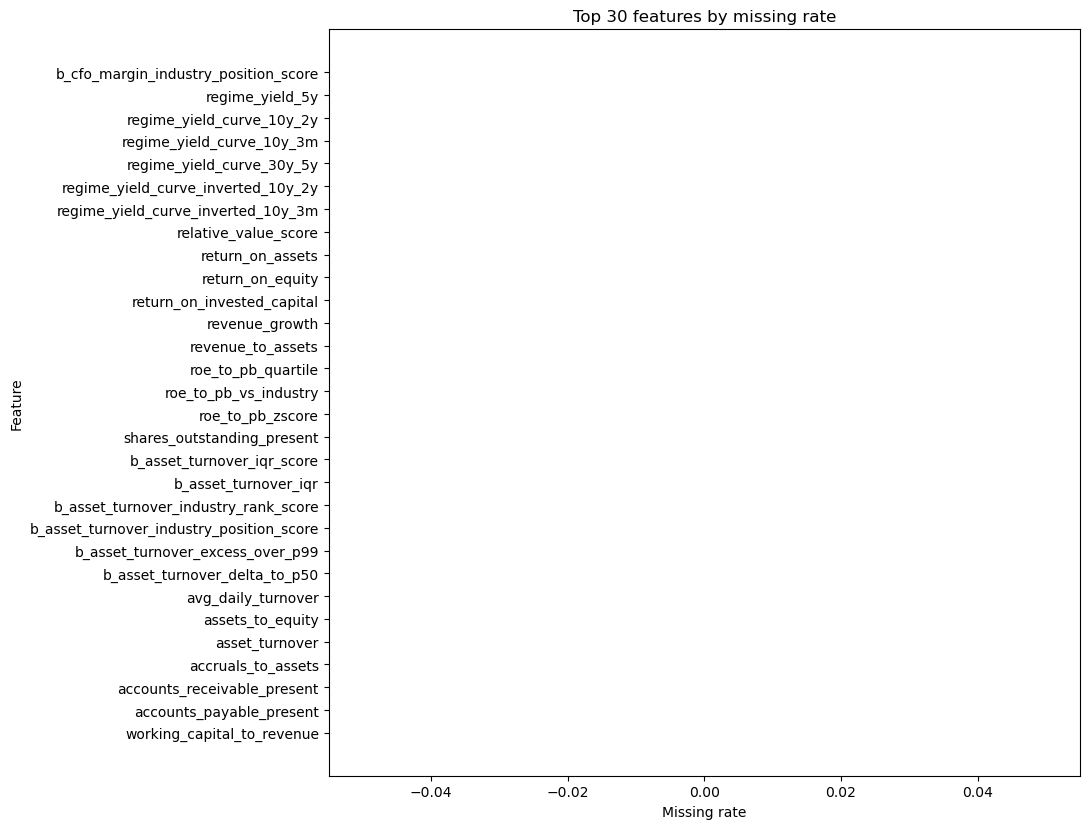

In [25]:
missing_plot = (
    final_feature_b_summary
    .sort_values("missing_rate", ascending=False)
    .head(TOP_MISSING_FEATURES_TO_PLOT)
    .sort_values("missing_rate")
)

if not missing_plot.empty:
    plt.figure(figsize=(10, 8))
    plt.barh(
        missing_plot["column"].str.replace("feature__", "", regex=False),
        missing_plot["missing_rate"]
    )
    plt.xlabel("Missing rate")
    plt.ylabel("Final Project B feature")
    plt.title("Final Project B features with the highest missingness")
    save_current_figure("final_feature_b_missingness")
    plt.show()

flagged_feature_checks = final_feature_b_summary[
    final_feature_b_summary[
        [
            "is_constant",
            "is_near_constant_99pct_zero",
            "high_missingness",
            "extreme_skew_abs_gt_10"
        ]
    ].any(axis=1)
].copy()

export_table(
    "final_feature_b_flagged_sanity_checks",
    flagged_feature_checks
)


## 8. Residual correlation diagnostics for the final Project B set

Correlation is summarised to document remaining redundancy. No feature is automatically removed in this notebook because the Project B list is treated as predefined.


In [26]:
# Spearman correlation is suitable for non-normal and partly ordinal financial features.
if len(final_feature_b_features) >= 2:
    final_feature_b_corr = (
        df_train[final_feature_b_features]
        .apply(pd.to_numeric, errors="coerce")
        .corr(method="spearman")
    )

    upper_triangle = final_feature_b_corr.abs().where(
        np.triu(np.ones(final_feature_b_corr.shape), k=1).astype(bool)
    )

    highly_correlated_pairs = (
        upper_triangle.stack()
        .reset_index()
        .rename(columns={
            "level_0": "feature_1",
            "level_1": "feature_2",
            0: "absolute_spearman"
        })
        .query("absolute_spearman > @CORR_THRESHOLD")
        .sort_values("absolute_spearman", ascending=False)
    )

    max_remaining_absolute_correlation = (
        upper_triangle.stack().max()
        if not upper_triangle.stack().empty
        else np.nan
    )
else:
    final_feature_b_corr = pd.DataFrame()
    highly_correlated_pairs = pd.DataFrame()
    max_remaining_absolute_correlation = np.nan

export_table(
    "final_feature_b_highly_correlated_pairs",
    highly_correlated_pairs,
    display_table=False
)

correlation_diagnostic_summary = pd.DataFrame([{
    "final_feature_b_count": len(final_feature_b_features),
    "correlation_threshold": CORR_THRESHOLD,
    "n_pairs_above_threshold": len(highly_correlated_pairs),
    "max_absolute_pairwise_spearman": max_remaining_absolute_correlation,
    "features_removed": 0,
    "interpretation": "Diagnostic only; no additional feature selection applied."
}])

export_table(
    "final_feature_b_correlation_diagnostic_summary",
    correlation_diagnostic_summary
)

display(correlation_diagnostic_summary)


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\tables\highly_correlated_feature_pairs.csv


,original_feature_count,after_quality_filter,correlation_threshold,dropped_for_high_correlation,decorrelated_feature_count
0,621,615,0.95,211,404


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\tables\correlation_filter_summary.csv
Decorrelated feature count: 404


Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\selected_feature_correlation_heatmap.png


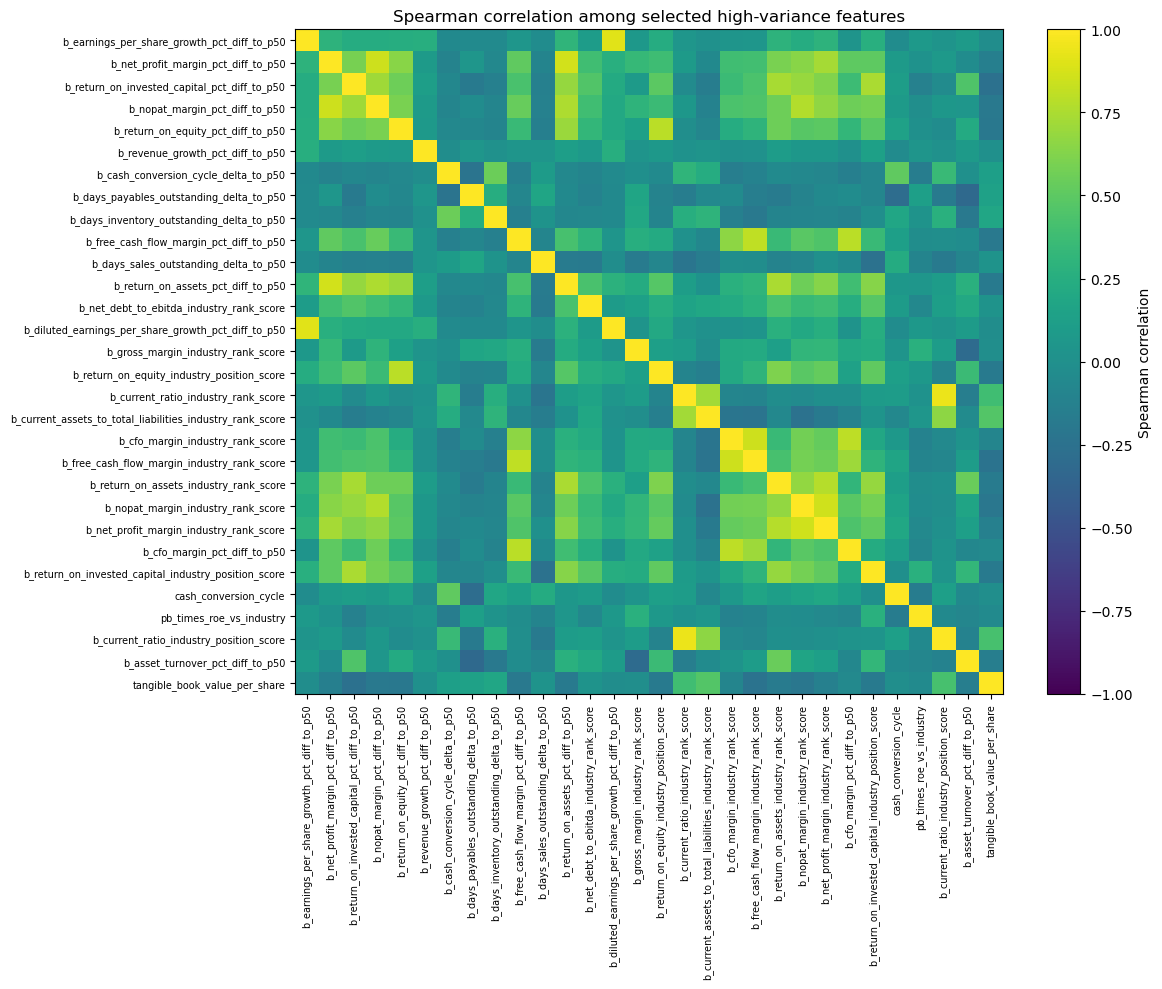

In [27]:
# Heatmap for a manageable high-variance subset of the final Project B features.
selected_corr_features = (
    final_feature_b_summary
    .query("column in @final_feature_b_features")
    .sort_values("std", ascending=False)
    .head(TOP_CORRELATION_FEATURES)["column"]
    .tolist()
)

if len(selected_corr_features) >= 2:
    selected_corr = (
        df_train[selected_corr_features]
        .apply(pd.to_numeric, errors="coerce")
        .corr(method="spearman")
    )

    plt.figure(figsize=(12, 10))
    image = plt.imshow(selected_corr, aspect="auto", vmin=-1, vmax=1)
    plt.colorbar(image, label="Spearman correlation")
    labels = [
        column.replace("feature__", "")
        for column in selected_corr_features
    ]
    plt.xticks(range(len(labels)), labels, rotation=90, fontsize=7)
    plt.yticks(range(len(labels)), labels, fontsize=7)
    plt.title("Selected correlations within the final Project B feature set")
    save_current_figure("final_feature_b_selected_correlation_heatmap")
    plt.show()


## 9. Selected distributions from the final Project B feature set

Only a small diagnostic subset is plotted. The complete numerical summary is exported as a table.


,feature
0,feature__b_earnings_per_share_growth_pct_diff_...
1,feature__b_net_profit_margin_pct_diff_to_p50
2,feature__b_return_on_invested_capital_pct_diff...
3,feature__b_nopat_margin_pct_diff_to_p50
4,feature__b_return_on_equity_pct_diff_to_p50
5,feature__b_revenue_growth_pct_diff_to_p50
6,feature__b_cash_conversion_cycle_delta_to_p50
7,feature__b_days_payables_outstanding_delta_to_p50
8,feature__b_days_inventory_outstanding_delta_to...
9,feature__b_free_cash_flow_margin_pct_diff_to_p50


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\tables\features_selected_for_distribution_plots.csv
Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_earnings_per_share_growth_pct_diff_to_p50.png


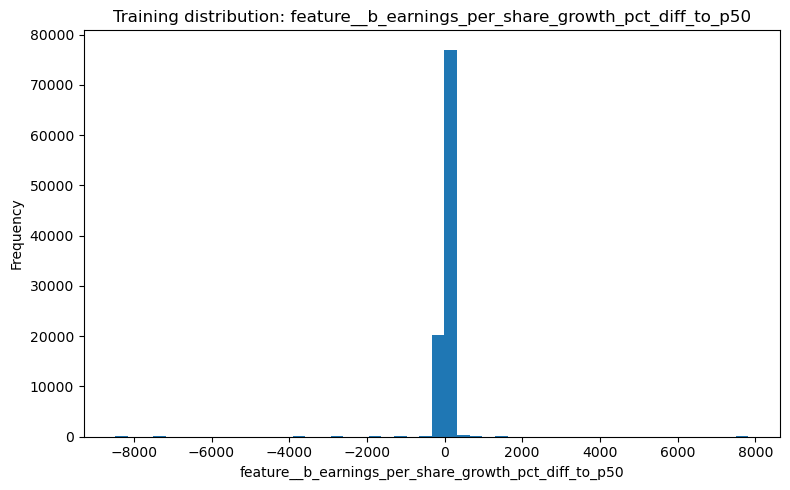

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_net_profit_margin_pct_diff_to_p50.png


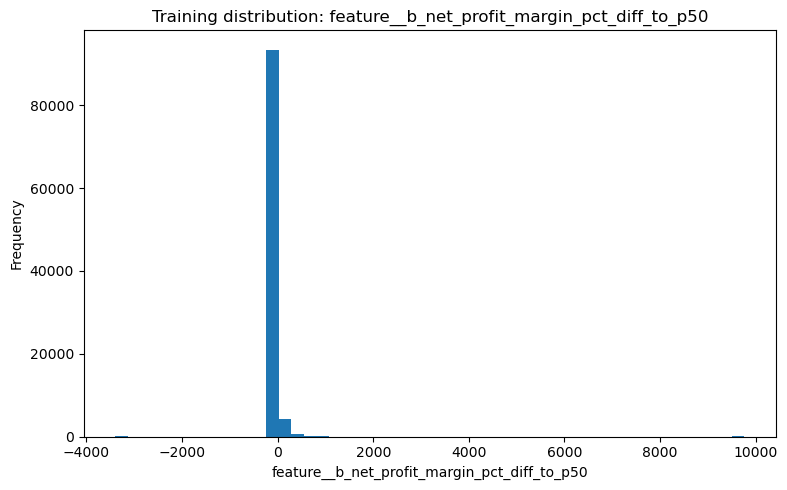

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_return_on_invested_capital_pct_diff_to_p50.png


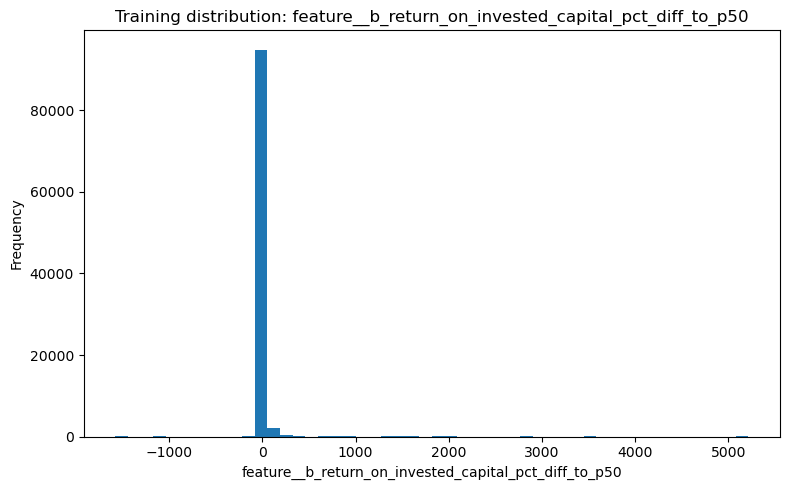

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_nopat_margin_pct_diff_to_p50.png


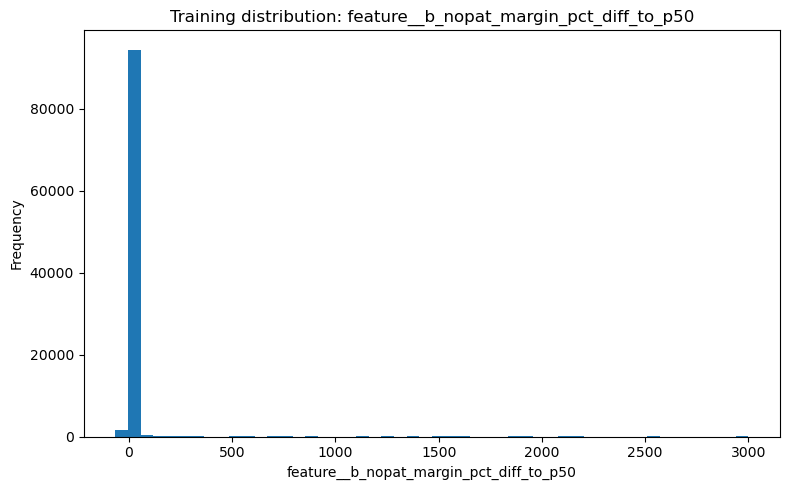

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_return_on_equity_pct_diff_to_p50.png


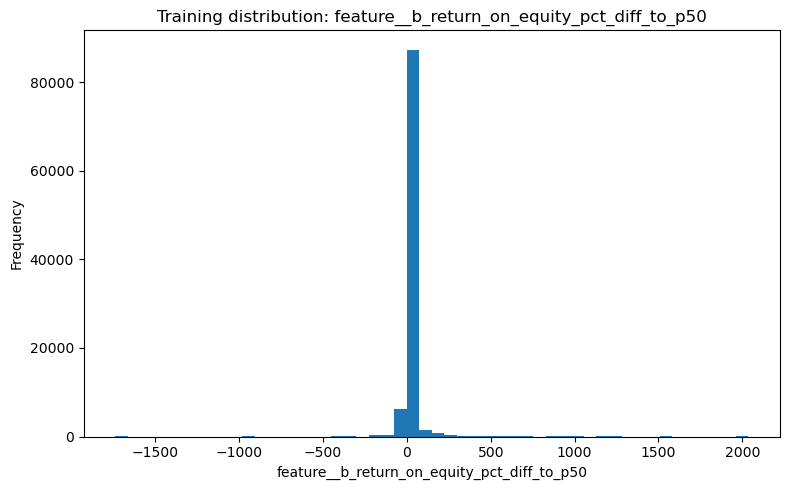

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_revenue_growth_pct_diff_to_p50.png


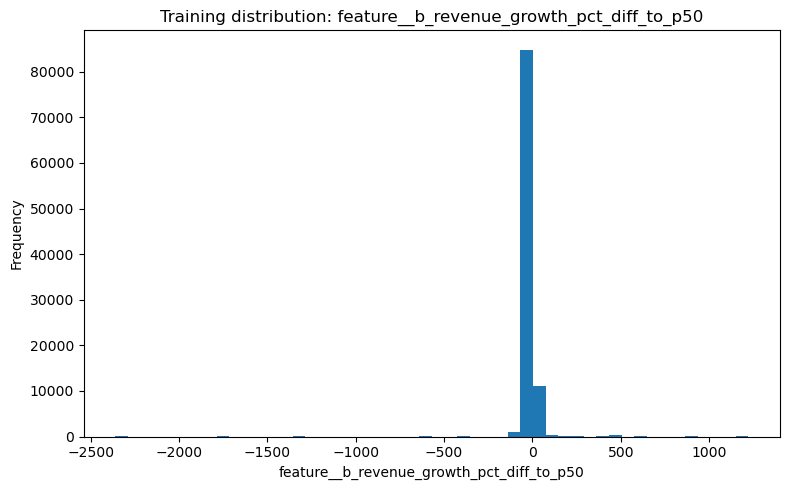

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_cash_conversion_cycle_delta_to_p50.png


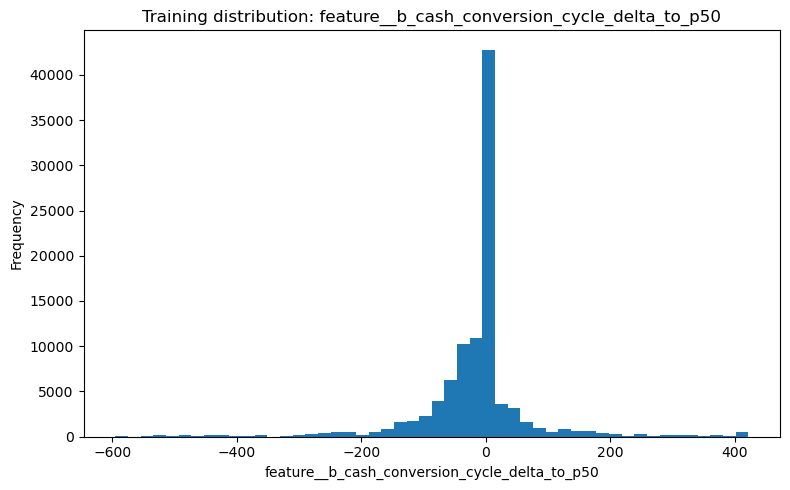

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_days_payables_outstanding_delta_to_p50.png


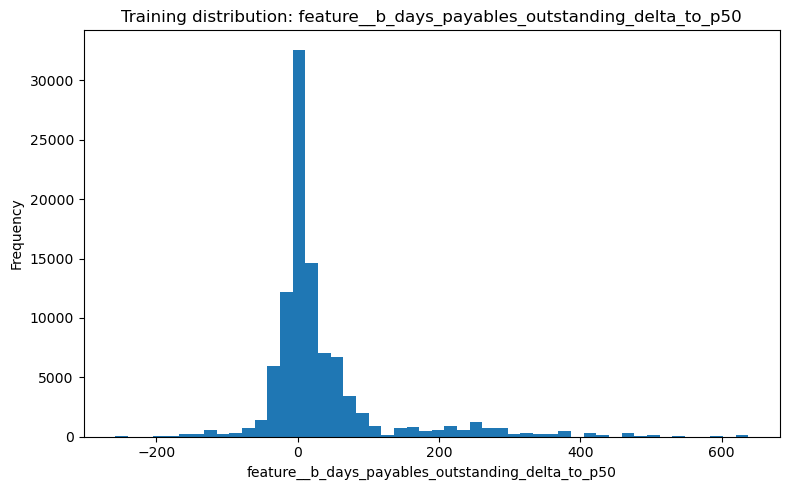

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_days_inventory_outstanding_delta_to_p50.png


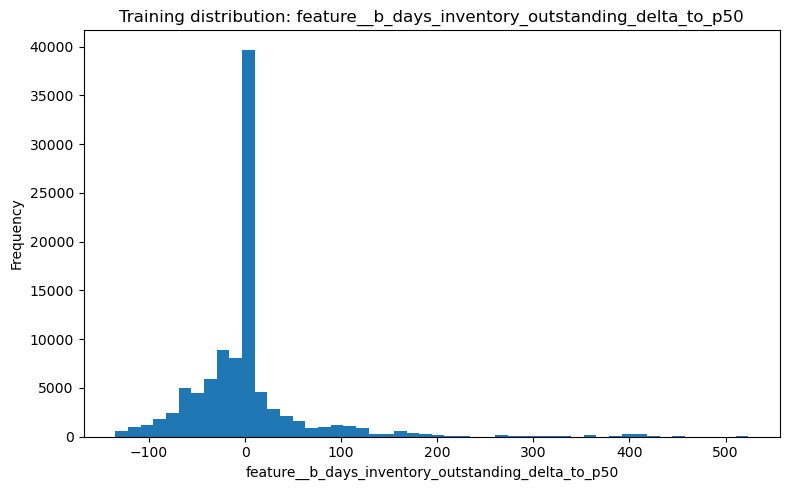

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_free_cash_flow_margin_pct_diff_to_p50.png


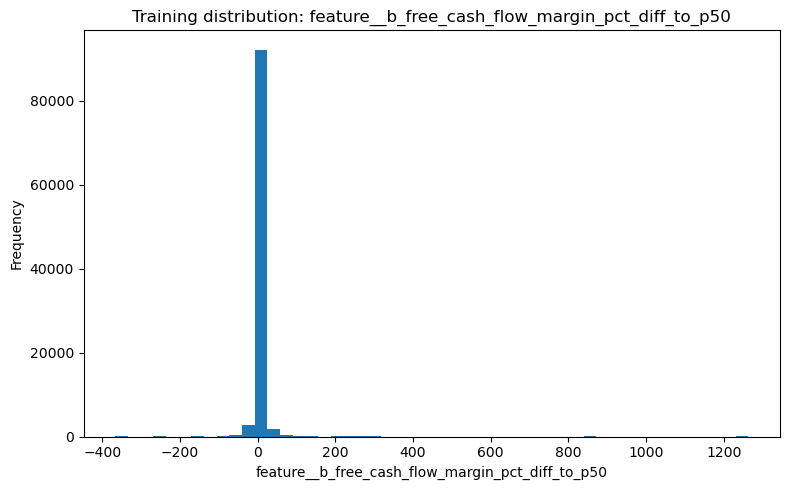

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_days_sales_outstanding_delta_to_p50.png


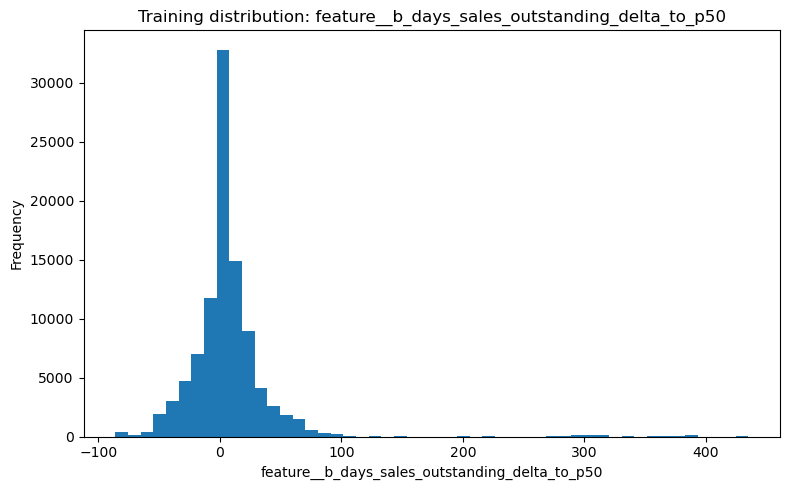

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_return_on_assets_pct_diff_to_p50.png


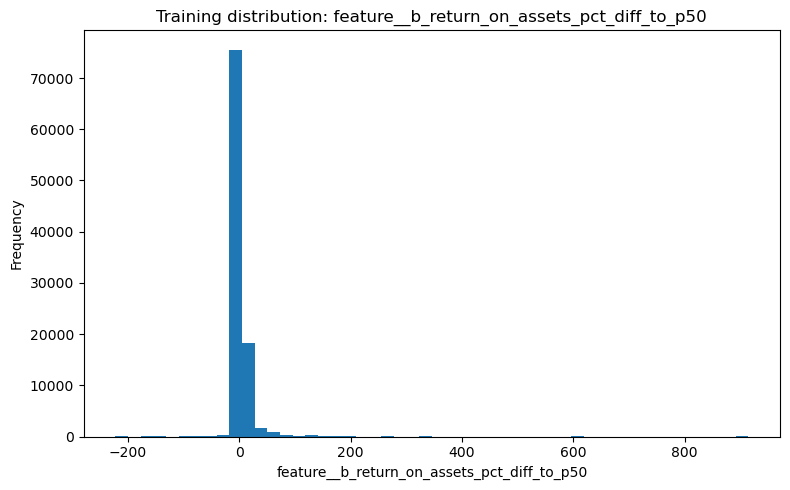

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_net_debt_to_ebitda_industry_rank_score.png


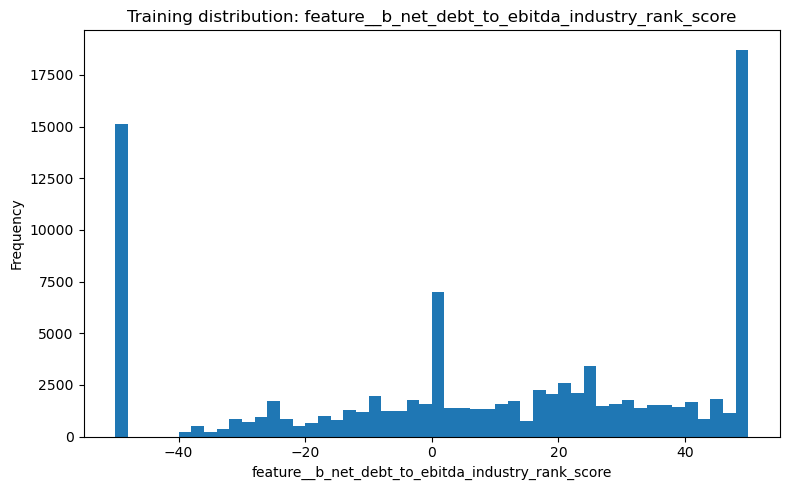

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_diluted_earnings_per_share_growth_pct_diff_to_p50.png


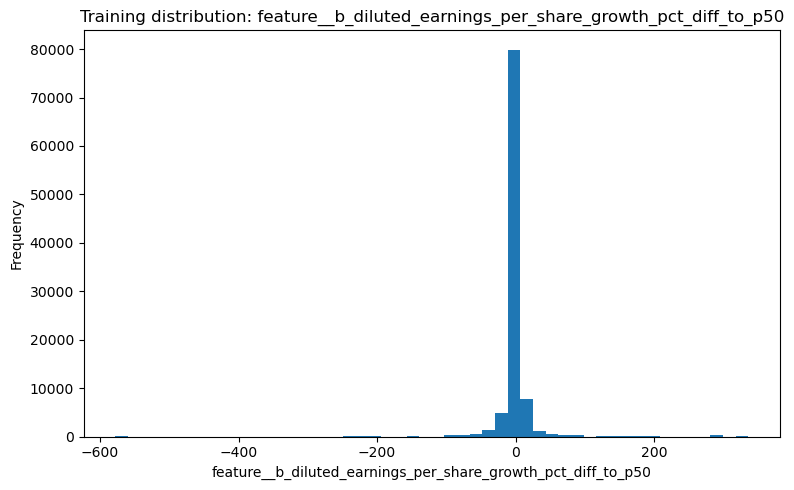

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_gross_margin_industry_rank_score.png


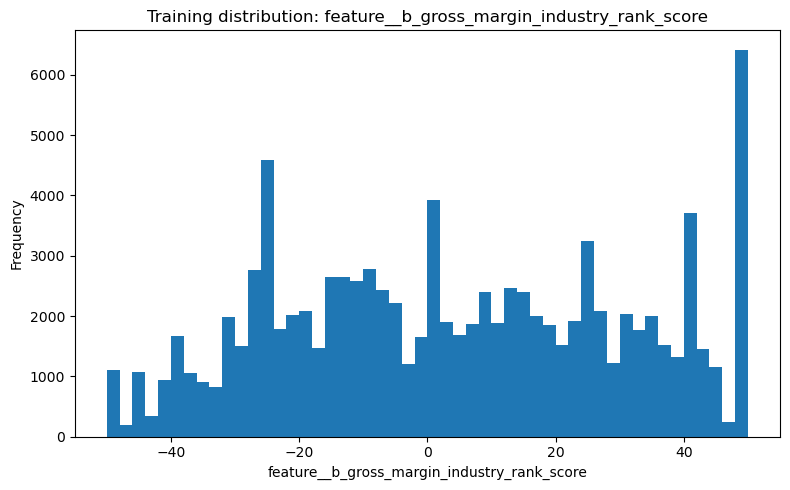

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_return_on_equity_industry_position_score.png


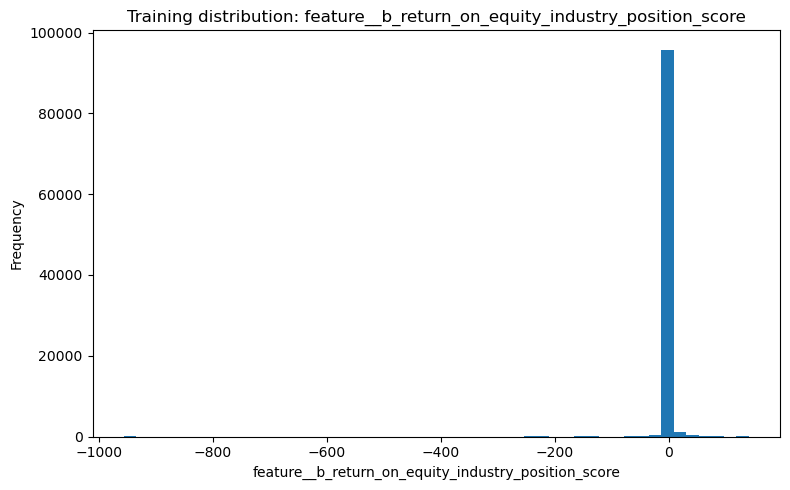

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_current_ratio_industry_rank_score.png


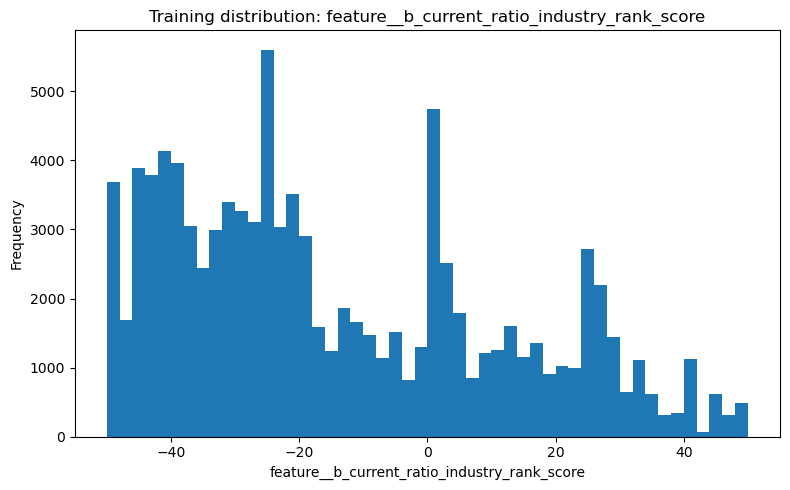

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_current_assets_to_total_liabilities_industry_rank_score.png


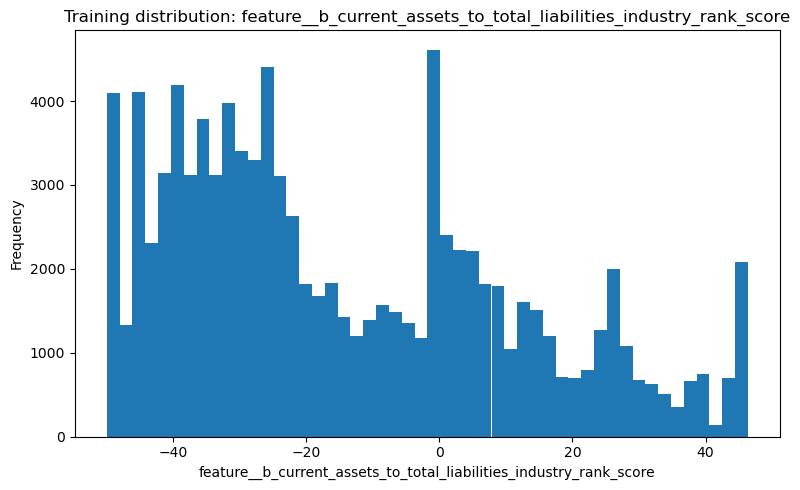

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_cfo_margin_industry_rank_score.png


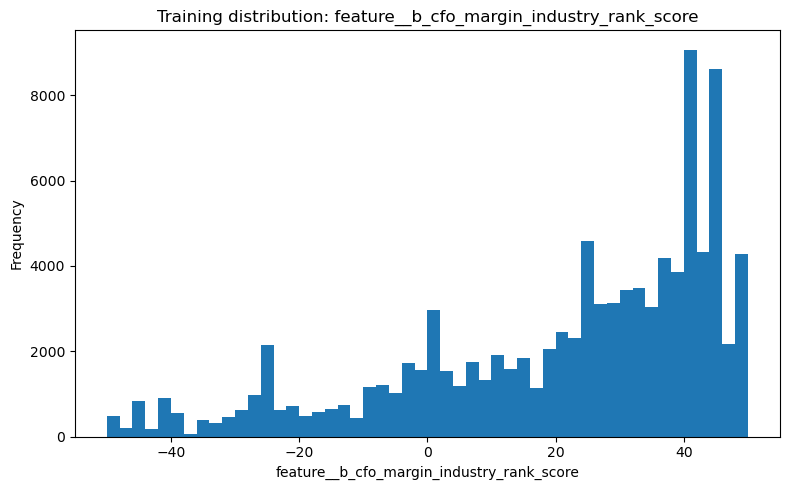

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\feature_histogram_feature_b_free_cash_flow_margin_industry_rank_score.png


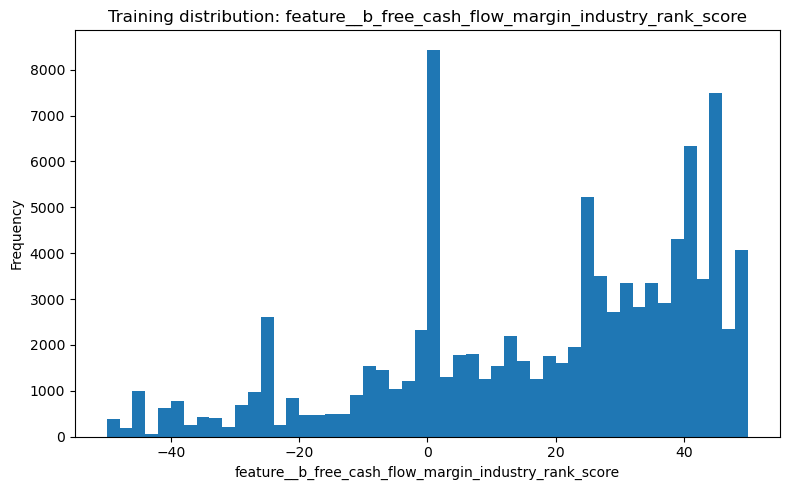

In [28]:
plot_features = (
    final_feature_b_summary[
        final_feature_b_summary["column"].isin(final_feature_b_features)
        & ~final_feature_b_summary["is_constant"]
    ]
    .sort_values(["missing_rate", "std"], ascending=[True, False])
    .head(TOP_VARIABLE_FEATURES_TO_PLOT)["column"]
    .tolist()
)

export_table(
    "final_feature_b_features_selected_for_distribution_plots",
    pd.DataFrame({"feature": plot_features})
)

for column in plot_features:
    values = pd.to_numeric(df_train[column], errors="coerce")
    values = values[np.isfinite(values)].dropna()

    if values.empty:
        continue

    # Clip plots only, not the data used in modelling.
    lower = values.quantile(0.01)
    upper = values.quantile(0.99)
    plotted_values = values.clip(lower=lower, upper=upper)

    plt.figure(figsize=(8, 5))
    plt.hist(plotted_values, bins=HISTOGRAM_BINS)
    plt.title(f"Training distribution (1st–99th percentile view): {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    save_current_figure(f"final_feature_b_histogram_{column}")
    plt.show()


## 10. Final Project B coverage across tickers and years

These checks identify features that are unavailable for particular securities or periods, and distinguish daily-changing from slow-moving or nearly static inputs.


In [29]:
coverage_rows = []

for feature in final_feature_b_features:
    numeric_values = pd.to_numeric(df_train[feature], errors="coerce")

    ticker_missing = (
        pd.DataFrame({
            "ticker": df_train[TICKER_COL],
            "is_missing": numeric_values.isna()
        })
        .groupby("ticker", dropna=False)["is_missing"]
        .mean()
    )

    year_missing = (
        pd.DataFrame({
            "year": df_train[YEAR_COL],
            "is_missing": numeric_values.isna()
        })
        .groupby("year", dropna=False)["is_missing"]
        .mean()
    )

    # Estimate within-ticker update frequency after chronological sorting.
    temp = pd.DataFrame({
        "ticker": df_train[TICKER_COL],
        "date": df_train[DATE_COL],
        "value": numeric_values
    }).sort_values(["ticker", "date"])

    previous = temp.groupby("ticker")["value"].shift(1)
    comparable = temp["value"].notna() & previous.notna()
    changed = comparable & temp["value"].ne(previous)

    change_rate = (
        changed.sum() / comparable.sum()
        if comparable.sum() > 0
        else np.nan
    )

    unique_per_ticker = (
        temp.groupby("ticker")["value"]
        .nunique(dropna=True)
    )

    coverage_rows.append({
        "feature": feature,
        "overall_missing_rate": numeric_values.isna().mean(),
        "max_ticker_missing_rate": ticker_missing.max(),
        "max_year_missing_rate": year_missing.max(),
        "tickers_fully_missing": int((ticker_missing == 1).sum()),
        "years_fully_missing": int((year_missing == 1).sum()),
        "median_unique_values_per_ticker": unique_per_ticker.median(),
        "mean_unique_values_per_ticker": unique_per_ticker.mean(),
        "within_ticker_change_rate": change_rate
    })

final_feature_b_coverage = pd.DataFrame(coverage_rows)

def assign_update_frequency(change_rate):
    if pd.isna(change_rate):
        return "unknown"
    if change_rate < 0.001:
        return "almost static"
    if change_rate < 0.05:
        return "slow-moving"
    return "frequently changing"

final_feature_b_coverage["update_frequency_group"] = (
    final_feature_b_coverage["within_ticker_change_rate"]
    .map(assign_update_frequency)
)

export_table(
    "final_feature_b_ticker_year_coverage_and_change_rate",
    final_feature_b_coverage,
    display_table=False
)

update_frequency_summary = (
    final_feature_b_coverage["update_frequency_group"]
    .value_counts(dropna=False)
    .rename_axis("update_frequency_group")
    .reset_index(name="n_features")
)

export_table(
    "final_feature_b_update_frequency_summary",
    update_frequency_summary
)

display(update_frequency_summary)

display(
    final_feature_b_coverage
    .sort_values(
        ["tickers_fully_missing", "max_ticker_missing_rate"],
        ascending=False
    )
    .head(20)
)


,feature,available_in_training_data,passes_quality_filter,retained_after_correlation_filter
0,feature__cash_to_debt,True,True,True
1,feature__cfo_to_assets,True,True,True
2,feature__interest_to_cfo,True,True,True
3,feature__interest_to_ebit,True,True,True
4,feature__interest_coverage_ebit,True,True,True
...,...,...,...,...
259,feature__price_to_ncav_per_share_quartile,True,True,True
260,feature__price_to_sales_vs_industry,True,True,True
261,feature__dividend_yield_quartile,True,True,True
262,feature__nopat_yield_ev_vs_industry,True,True,False


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\tables\project_b_feature_coverage.csv


## 11. Target EDA — training data only

In [30]:
available_target_columns = target_cols.copy()

# Raw label fallback: include selected raw labels when no derived targets exist.
if not available_target_columns:
    available_target_columns = label_cols.copy()

if SELECTED_TARGETS is not None:
    available_target_columns = [
        column for column in SELECTED_TARGETS
        if column in df_train.columns
    ]

print("Targets included in EDA:")
for column in available_target_columns:
    print(" -", column)

target_summary = numeric_column_summary(
    df_train,
    available_target_columns
)

target_summary["positive_rate"] = [
    (
        pd.to_numeric(df_train[column], errors="coerce") > 0
    ).mean()
    for column in target_summary["column"]
]

target_summary["negative_rate"] = [
    (
        pd.to_numeric(df_train[column], errors="coerce") < 0
    ).mean()
    for column in target_summary["column"]
]

export_table("target_summary_overall", target_summary)


Targets included in EDA:
 - target__pi_hindsight_entry_6bins
 - target__pi_hindsight_entry_long
 - target__pi_hindsight_entry_original
 - target__pi_hindsight_entry_positive
 - target__rl_long_action_binary
 - target__rl_long_action_quality
 - target__rl_long_current_pnl
 - target__rl_long_reward


,column,dtype,count,missing_count,missing_rate,zero_count,zero_rate,n_unique,mean,std,...,p01,p05,p25,median,p75,p95,p99,max,positive_rate,negative_rate
0,target__pi_hindsight_entry_6bins,Int64,98419,0,0.0,77569,0.788151,6,0.840193,1.747523,...,0.000000,0.0000,0.00000,0.000000,0.000000,5.000000,5.000000,5.0000,0.211849,0.000000
1,target__pi_hindsight_entry_long,float64,98419,0,0.0,77569,0.788151,13337,0.097766,0.224727,...,0.000000,0.0000,0.00000,0.000000,0.000000,0.573514,1.000000,1.0000,0.211849,0.000000
2,target__pi_hindsight_entry_original,Int64,98419,0,0.0,86494,0.878834,2,0.121166,0.326321,...,0.000000,0.0000,0.00000,0.000000,0.000000,1.000000,1.000000,1.0000,0.121166,0.000000
3,target__pi_hindsight_entry_positive,Int64,98419,0,0.0,77569,0.788151,2,0.211849,0.408621,...,0.000000,0.0000,0.00000,0.000000,0.000000,1.000000,1.000000,1.0000,0.211849,0.000000
4,target__rl_long_action_binary,int64,98419,0,0.0,50579,0.513915,2,0.486085,0.499809,...,0.000000,0.0000,0.00000,0.000000,1.000000,1.000000,1.000000,1.0000,0.486085,0.000000
5,target__rl_long_action_quality,float64,98419,0,0.0,0,0.000000,8156,0.000041,2.477705,...,-2.534800,-2.5348,-2.40195,-2.172100,1.959500,3.349300,3.349700,3.3498,0.486085,0.513915
6,target__rl_long_current_pnl,float64,98419,0,0.0,0,0.000000,63592,437.625336,2321.702321,...,-1598.287691,-896.6958,-430.78035,-252.627375,408.157475,3281.647079,6057.164814,54391.8375,0.486085,0.513915
7,target__rl_long_reward,float64,98419,0,0.0,0,0.000000,11655,-0.531347,2.683590,...,-3.284800,-3.2848,-3.15240,-2.808700,1.578500,3.118100,3.122800,3.2146,0.486085,0.513915


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\tables\target_summary_overall.csv


,column,dtype,count,missing_count,missing_rate,zero_count,zero_rate,n_unique,mean,std,...,p01,p05,p25,median,p75,p95,p99,max,positive_rate,negative_rate
0,target__pi_hindsight_entry_6bins,Int64,98419,0,0.0,77569,0.788151,6,0.840193,1.747523,...,0.000000,0.0000,0.00000,0.000000,0.000000,5.000000,5.000000,5.0000,0.211849,0.000000
1,target__pi_hindsight_entry_long,float64,98419,0,0.0,77569,0.788151,13337,0.097766,0.224727,...,0.000000,0.0000,0.00000,0.000000,0.000000,0.573514,1.000000,1.0000,0.211849,0.000000
2,target__pi_hindsight_entry_original,Int64,98419,0,0.0,86494,0.878834,2,0.121166,0.326321,...,0.000000,0.0000,0.00000,0.000000,0.000000,1.000000,1.000000,1.0000,0.121166,0.000000
3,target__pi_hindsight_entry_positive,Int64,98419,0,0.0,77569,0.788151,2,0.211849,0.408621,...,0.000000,0.0000,0.00000,0.000000,0.000000,1.000000,1.000000,1.0000,0.211849,0.000000
4,target__rl_long_action_binary,int64,98419,0,0.0,50579,0.513915,2,0.486085,0.499809,...,0.000000,0.0000,0.00000,0.000000,1.000000,1.000000,1.000000,1.0000,0.486085,0.000000
5,target__rl_long_action_quality,float64,98419,0,0.0,0,0.000000,8156,0.000041,2.477705,...,-2.534800,-2.5348,-2.40195,-2.172100,1.959500,3.349300,3.349700,3.3498,0.486085,0.513915
6,target__rl_long_current_pnl,float64,98419,0,0.0,0,0.000000,63592,437.625336,2321.702321,...,-1598.287691,-896.6958,-430.78035,-252.627375,408.157475,3281.647079,6057.164814,54391.8375,0.486085,0.513915
7,target__rl_long_reward,float64,98419,0,0.0,0,0.000000,11655,-0.531347,2.683590,...,-3.284800,-3.2848,-3.15240,-2.808700,1.578500,3.118100,3.122800,3.2146,0.486085,0.513915


Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_distribution_target_pi_hindsight_entry_6bins.png


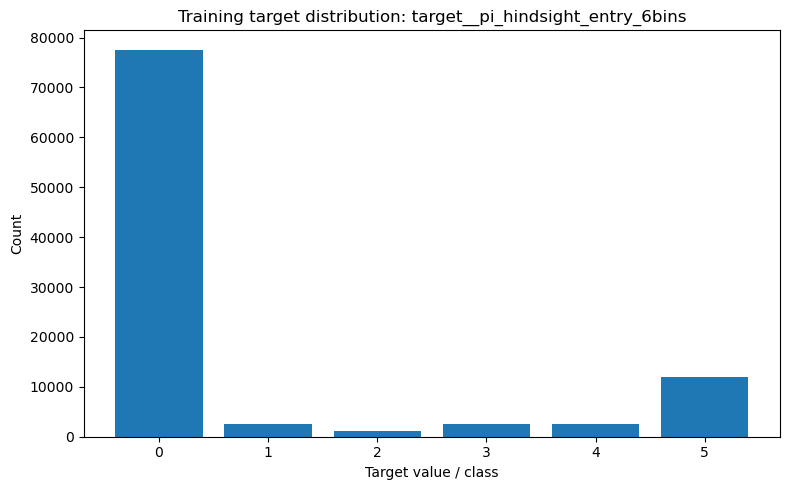

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_distribution_target_pi_hindsight_entry_long.png


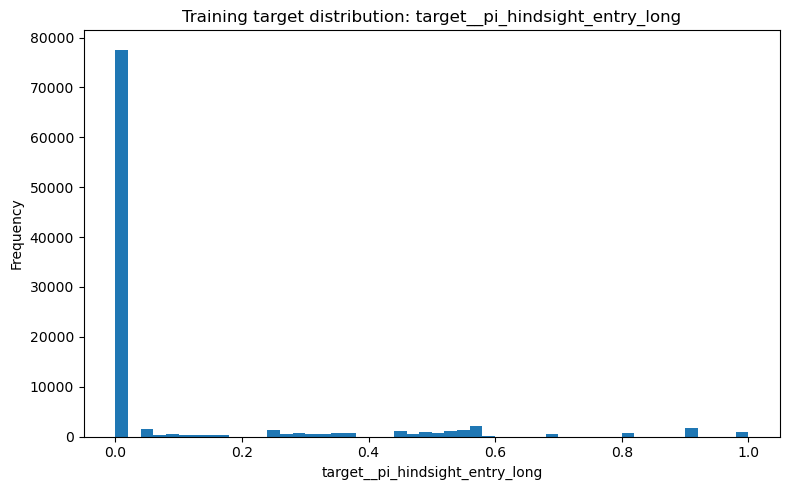

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_distribution_target_pi_hindsight_entry_original.png


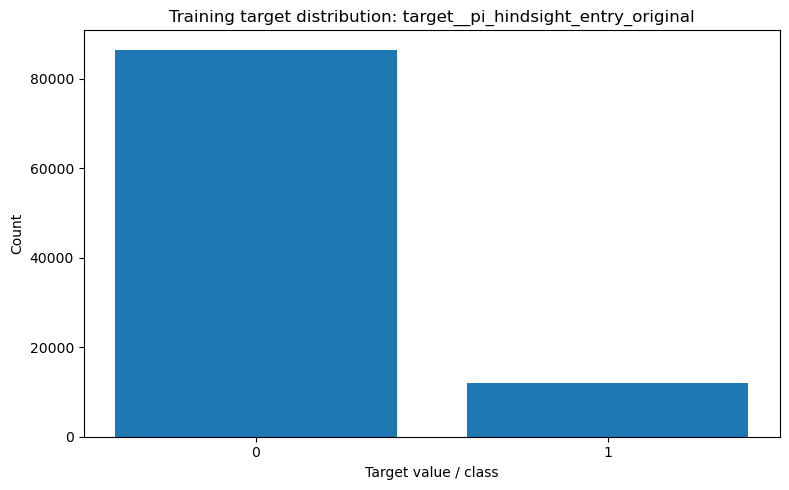

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_distribution_target_pi_hindsight_entry_positive.png


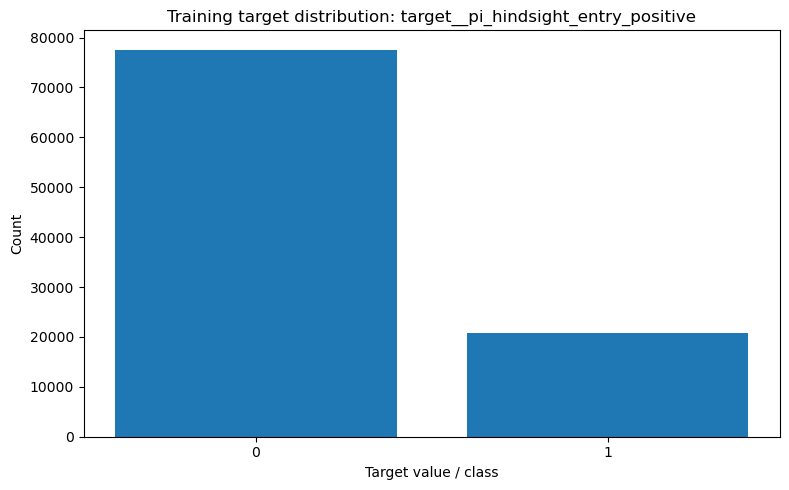

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_distribution_target_rl_long_action_binary.png


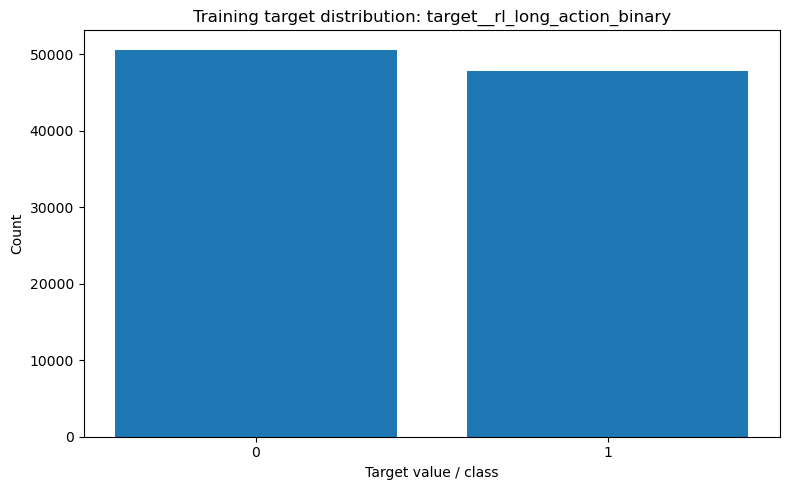

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_distribution_target_rl_long_action_quality.png


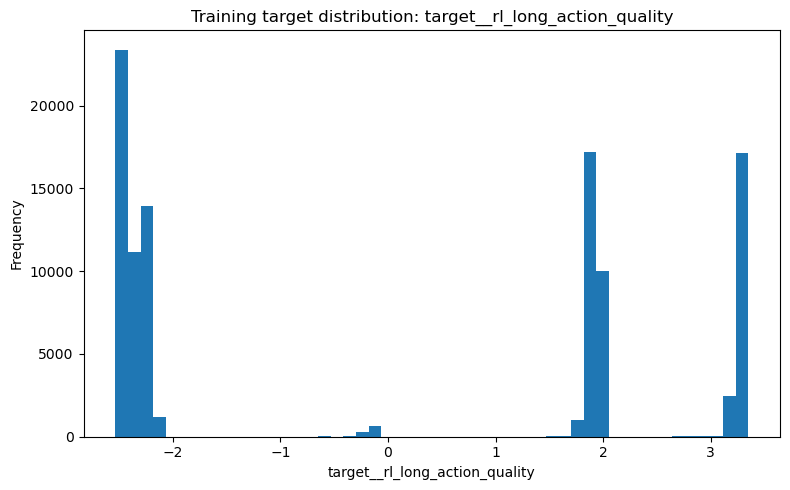

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_distribution_target_rl_long_current_pnl.png


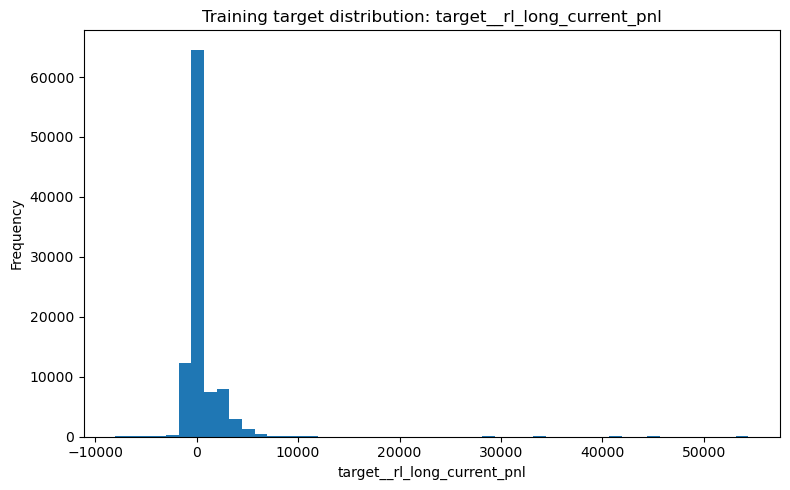

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_distribution_target_rl_long_reward.png


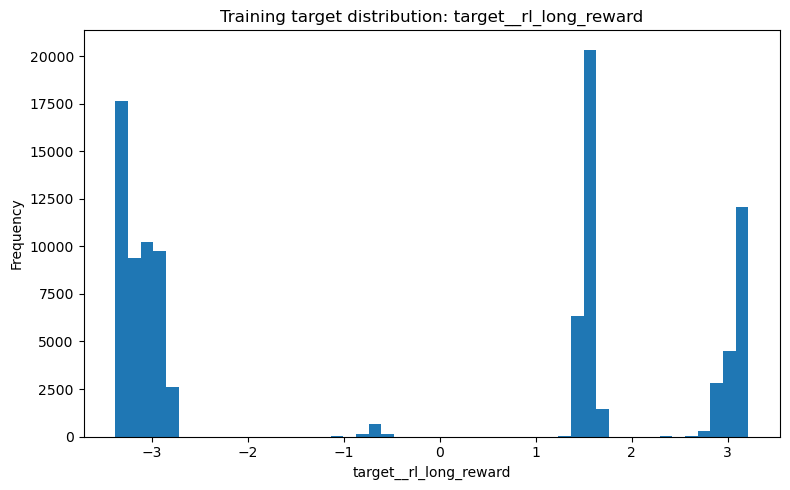

In [31]:
for column in available_target_columns:
    values = pd.to_numeric(df_train[column], errors="coerce").dropna()

    if values.empty:
        continue

    plt.figure(figsize=(8, 5))

    n_unique = values.nunique()
    if n_unique <= 20:
        counts = values.value_counts().sort_index()
        plt.bar(counts.index.astype(str), counts.values)
        plt.xlabel("Target value / class")
        plt.ylabel("Count")
    else:
        plt.hist(values, bins=HISTOGRAM_BINS)
        plt.xlabel(column)
        plt.ylabel("Frequency")

    plt.title(f"Training target distribution: {column}")
    save_current_figure(f"target_distribution_{column}")
    plt.show()


## 12. Target distribution by year

,target,year,n_obs,mean,std,min,median,max,zero_rate,positive_rate,negative_rate
0,target__pi_hindsight_entry_6bins,2020,24650,1.03931,1.886995,0.0,0.0,5.0,0.735132,0.264868,0.000000
1,target__pi_hindsight_entry_6bins,2021,24696,0.853782,1.768902,0.0,0.0,5.0,0.790614,0.209386,0.000000
2,target__pi_hindsight_entry_6bins,2022,24598,0.665826,1.578213,0.0,0.0,5.0,0.826205,0.173795,0.000000
3,target__pi_hindsight_entry_6bins,2023,24475,0.801185,1.720911,0.0,0.0,5.0,0.800817,0.199183,0.000000
4,target__pi_hindsight_entry_long,2020,24650,0.12308,0.252567,0.0,0.0,1.0,0.735132,0.264868,0.000000
5,target__pi_hindsight_entry_long,2021,24696,0.099532,0.224878,0.0,0.0,1.0,0.790614,0.209386,0.000000
6,target__pi_hindsight_entry_long,2022,24598,0.075652,0.198147,0.0,0.0,1.0,0.826205,0.173795,0.000000
7,target__pi_hindsight_entry_long,2023,24475,0.092712,0.217228,0.0,0.0,1.0,0.800817,0.199183,0.000000
8,target__pi_hindsight_entry_original,2020,24650,0.150629,0.357694,0.0,0.0,1.0,0.849371,0.150629,0.000000
9,target__pi_hindsight_entry_original,2021,24696,0.124312,0.329943,0.0,0.0,1.0,0.875688,0.124312,0.000000


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\tables\target_summary_by_year.csv
Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_yearly_mean_target_pi_hindsight_entry_6bins.png


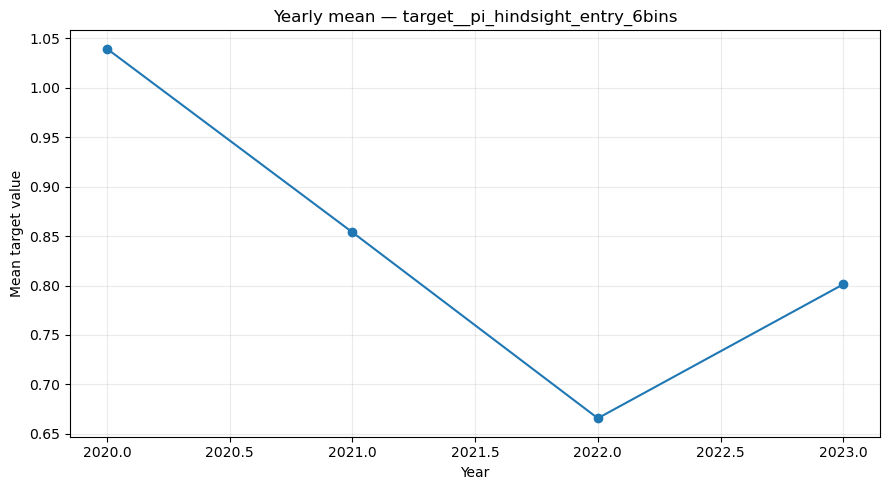

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_yearly_mean_target_pi_hindsight_entry_long.png


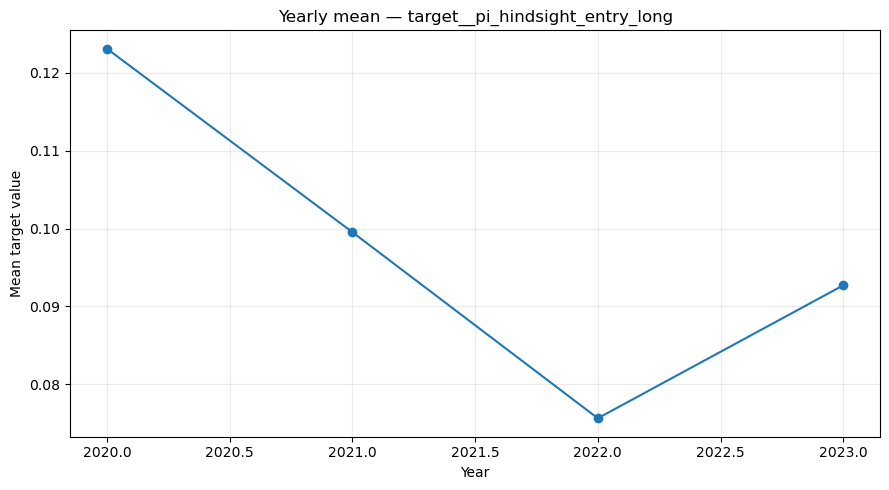

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_yearly_mean_target_pi_hindsight_entry_original.png


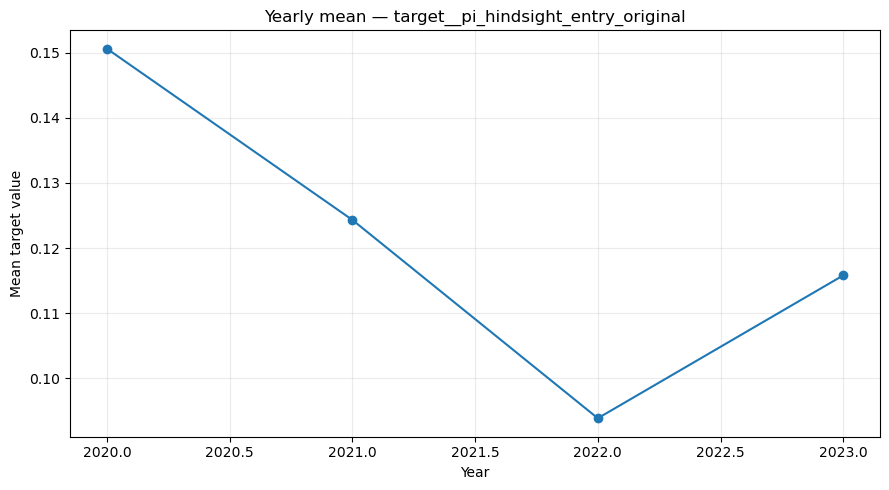

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_yearly_mean_target_pi_hindsight_entry_positive.png


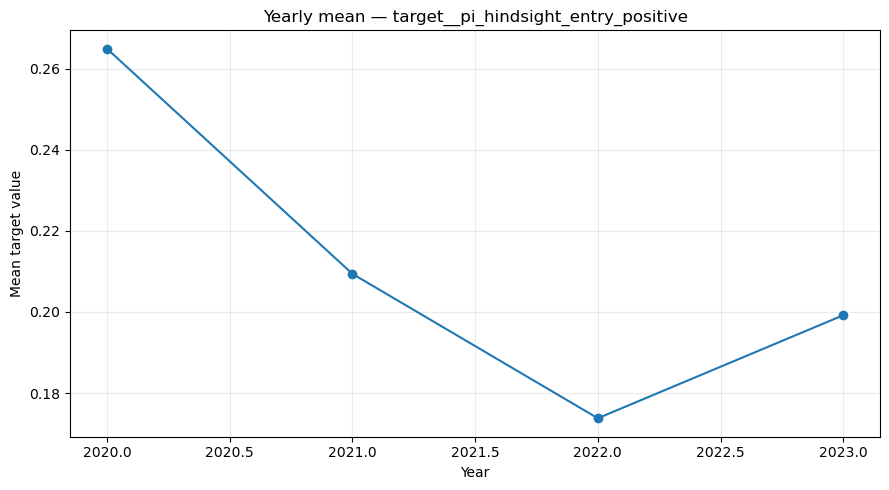

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_yearly_mean_target_rl_long_action_binary.png


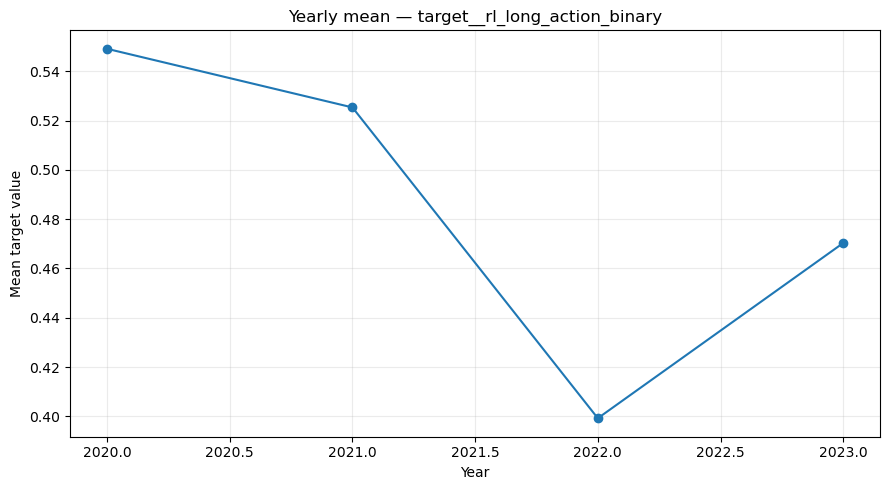

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_yearly_mean_target_rl_long_action_quality.png


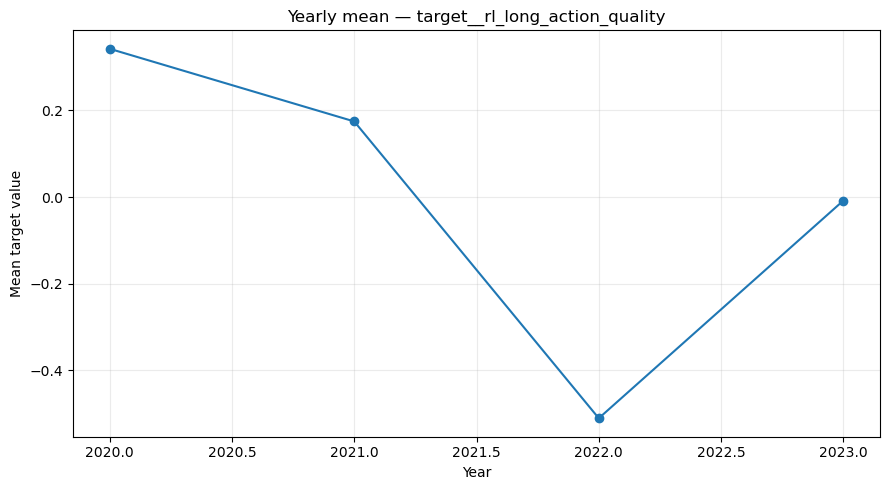

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_yearly_mean_target_rl_long_current_pnl.png


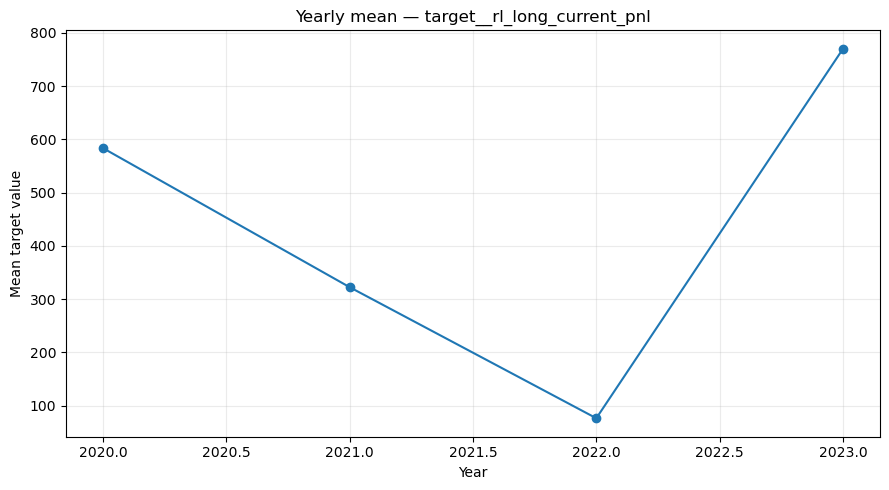

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_yearly_mean_target_rl_long_reward.png


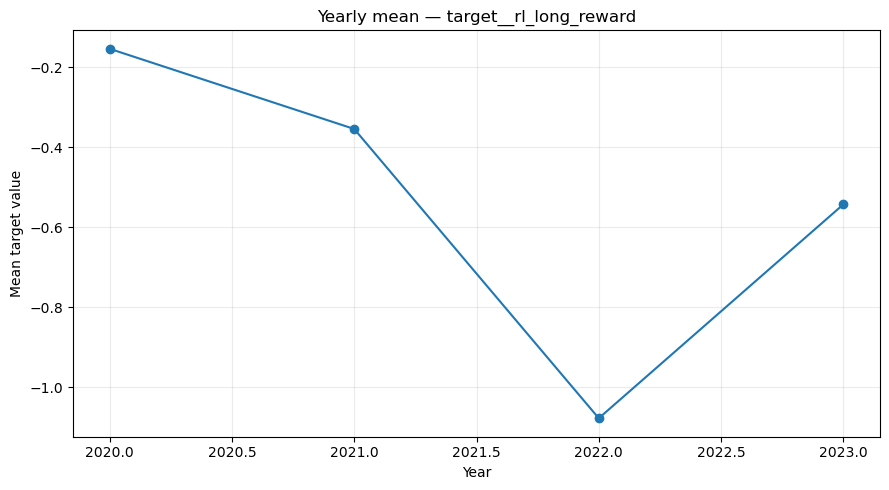

In [32]:
target_year_rows = []

for column in available_target_columns:
    temporary = df_train[[YEAR_COL, column]].copy()
    temporary[column] = pd.to_numeric(
        temporary[column],
        errors="coerce"
    )
    temporary = temporary.dropna(subset=[YEAR_COL, column])

    yearly = (
        temporary.groupby(YEAR_COL)[column]
        .agg(
            n_obs="size",
            mean="mean",
            std="std",
            min="min",
            median="median",
            max="max"
        )
        .reset_index()
    )

    rates = (
        temporary.groupby(YEAR_COL)[column]
        .apply(
            lambda values: pd.Series({
                "zero_rate": (values == 0).mean(),
                "positive_rate": (values > 0).mean(),
                "negative_rate": (values < 0).mean()
            })
        )
        .unstack()
        .reset_index()
    )

    yearly = yearly.merge(rates, on=YEAR_COL, how="left")
    yearly.insert(0, "target", column)
    target_year_rows.append(yearly)

target_by_year = (
    pd.concat(target_year_rows, ignore_index=True)
    if target_year_rows
    else pd.DataFrame()
)

export_table("target_summary_by_year", target_by_year)

for column in available_target_columns:
    plot_data = target_by_year[
        target_by_year["target"] == column
    ].sort_values(YEAR_COL)

    if plot_data.empty:
        continue

    plt.figure(figsize=(9, 5))
    plt.plot(
        plot_data[YEAR_COL],
        plot_data["mean"],
        marker="o"
    )
    plt.title(f"Yearly mean — {column}")
    plt.xlabel("Year")
    plt.ylabel("Mean target value")
    plt.grid(alpha=0.25)
    save_current_figure(f"target_yearly_mean_{column}")
    plt.show()


## 13. Target distribution by ticker

,target,attr__ticker,n_obs,mean,std,min,median,max,zero_rate,positive_rate,negative_rate
0,target__pi_hindsight_entry_6bins,AAPL,1006,1.244533,2.030083,0.0,0.0,5.0,0.697813,0.302187,0.000000
1,target__pi_hindsight_entry_6bins,ABBV,1006,0.799205,1.731028,0.0,0.0,5.0,0.805169,0.194831,0.000000
2,target__pi_hindsight_entry_6bins,ABT,1006,0.708748,1.634109,0.0,0.0,5.0,0.823062,0.176938,0.000000
3,target__pi_hindsight_entry_6bins,ACN,1006,1.007952,1.886305,0.0,0.0,5.0,0.753479,0.246521,0.000000
4,target__pi_hindsight_entry_6bins,ADBE,1006,1.093439,1.926308,0.0,0.0,5.0,0.726640,0.273360,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
779,target__rl_long_reward,UPS,1006,-0.929025,2.598605,-3.2848,-2.89865,3.1631,0.000000,0.424453,0.575547
780,target__rl_long_reward,VZ,1006,-2.171508,1.952407,-3.3848,-3.14425,2.6706,0.000000,0.200795,0.799205
781,target__rl_long_reward,WFC,1006,-0.599331,2.700635,-3.2848,-2.83995,3.1526,0.000000,0.472167,0.527833
782,target__rl_long_reward,WMT,1006,-0.319173,2.731531,-3.2848,1.40305,3.1228,0.000000,0.500994,0.499006


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\tables\target_summary_by_ticker.csv
Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_mean_by_ticker_target_pi_hindsight_entry_6bins.png


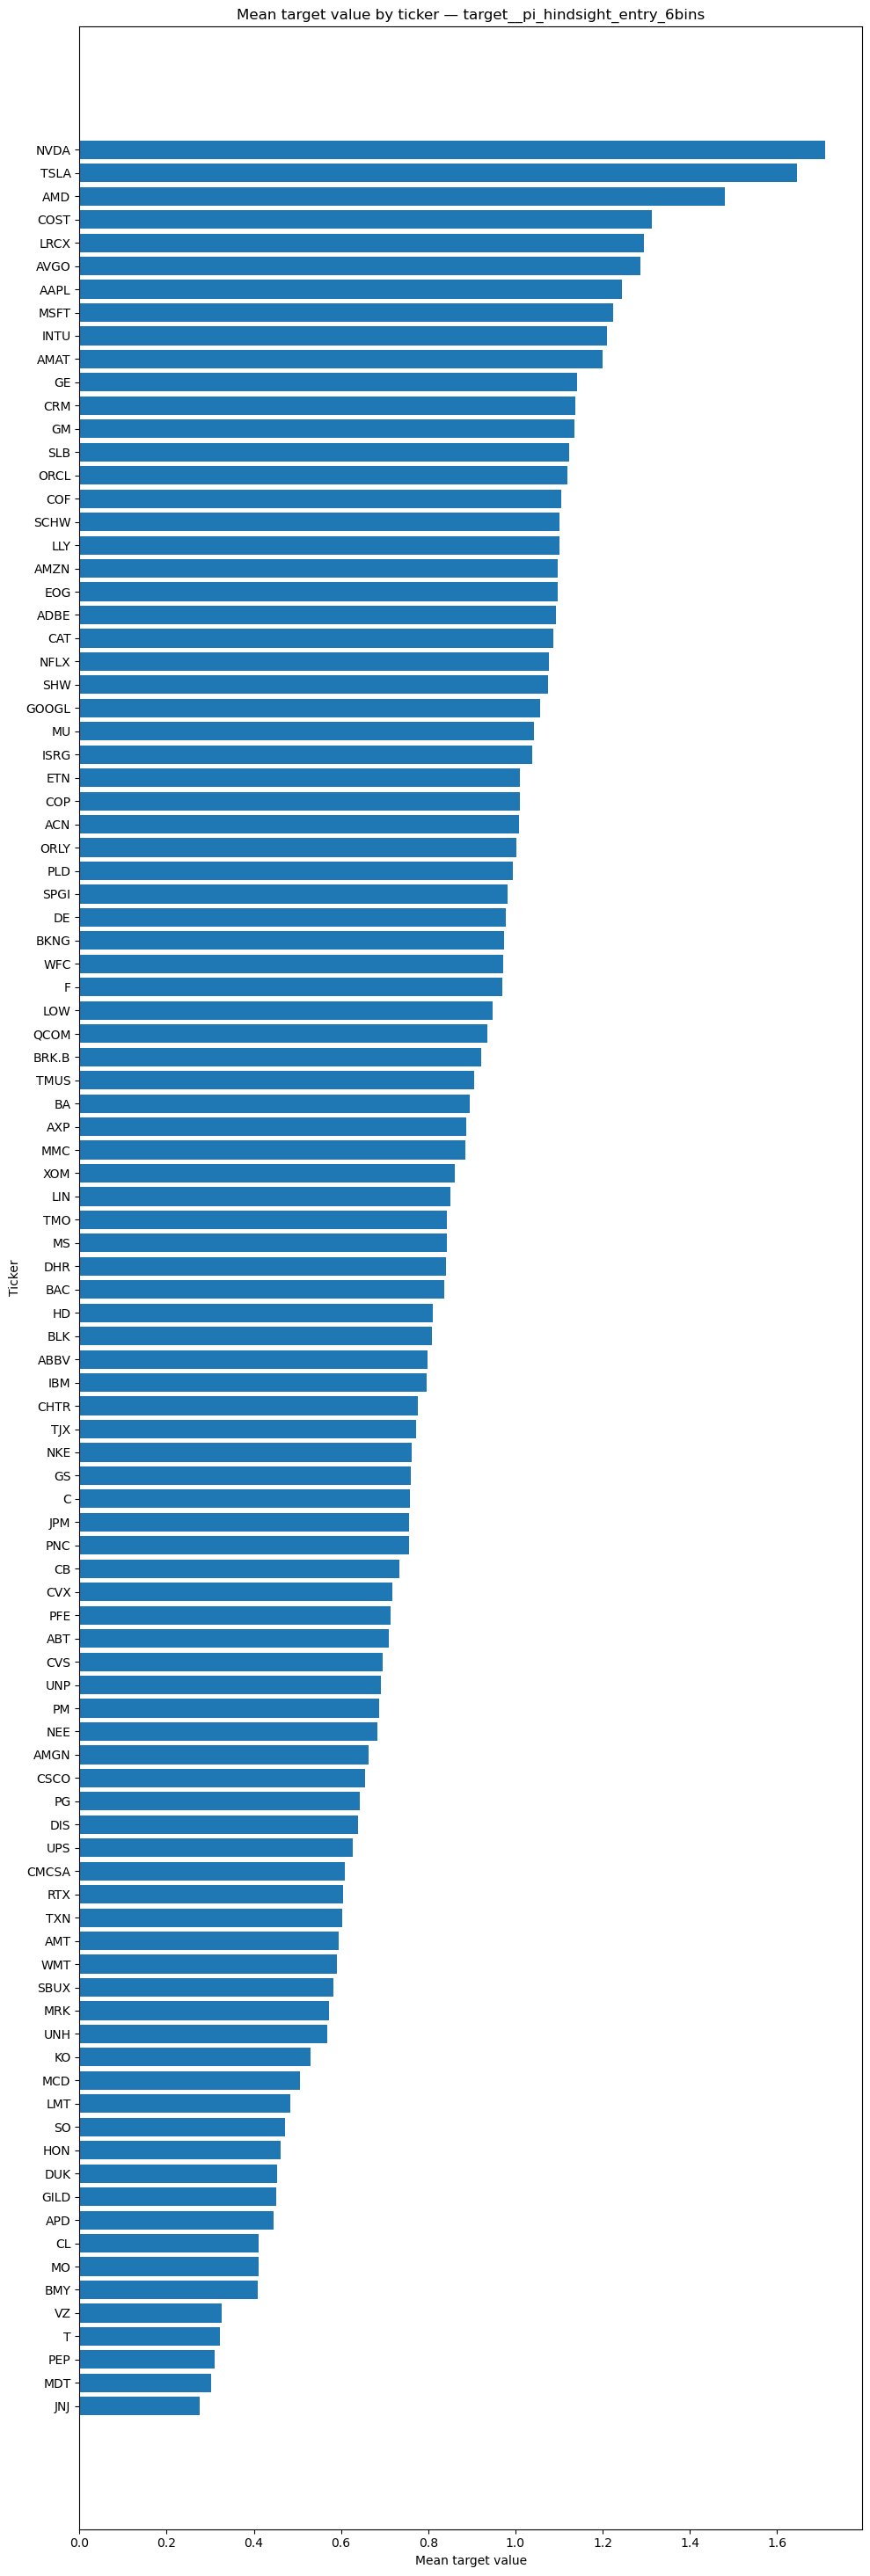

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_mean_by_ticker_target_pi_hindsight_entry_long.png


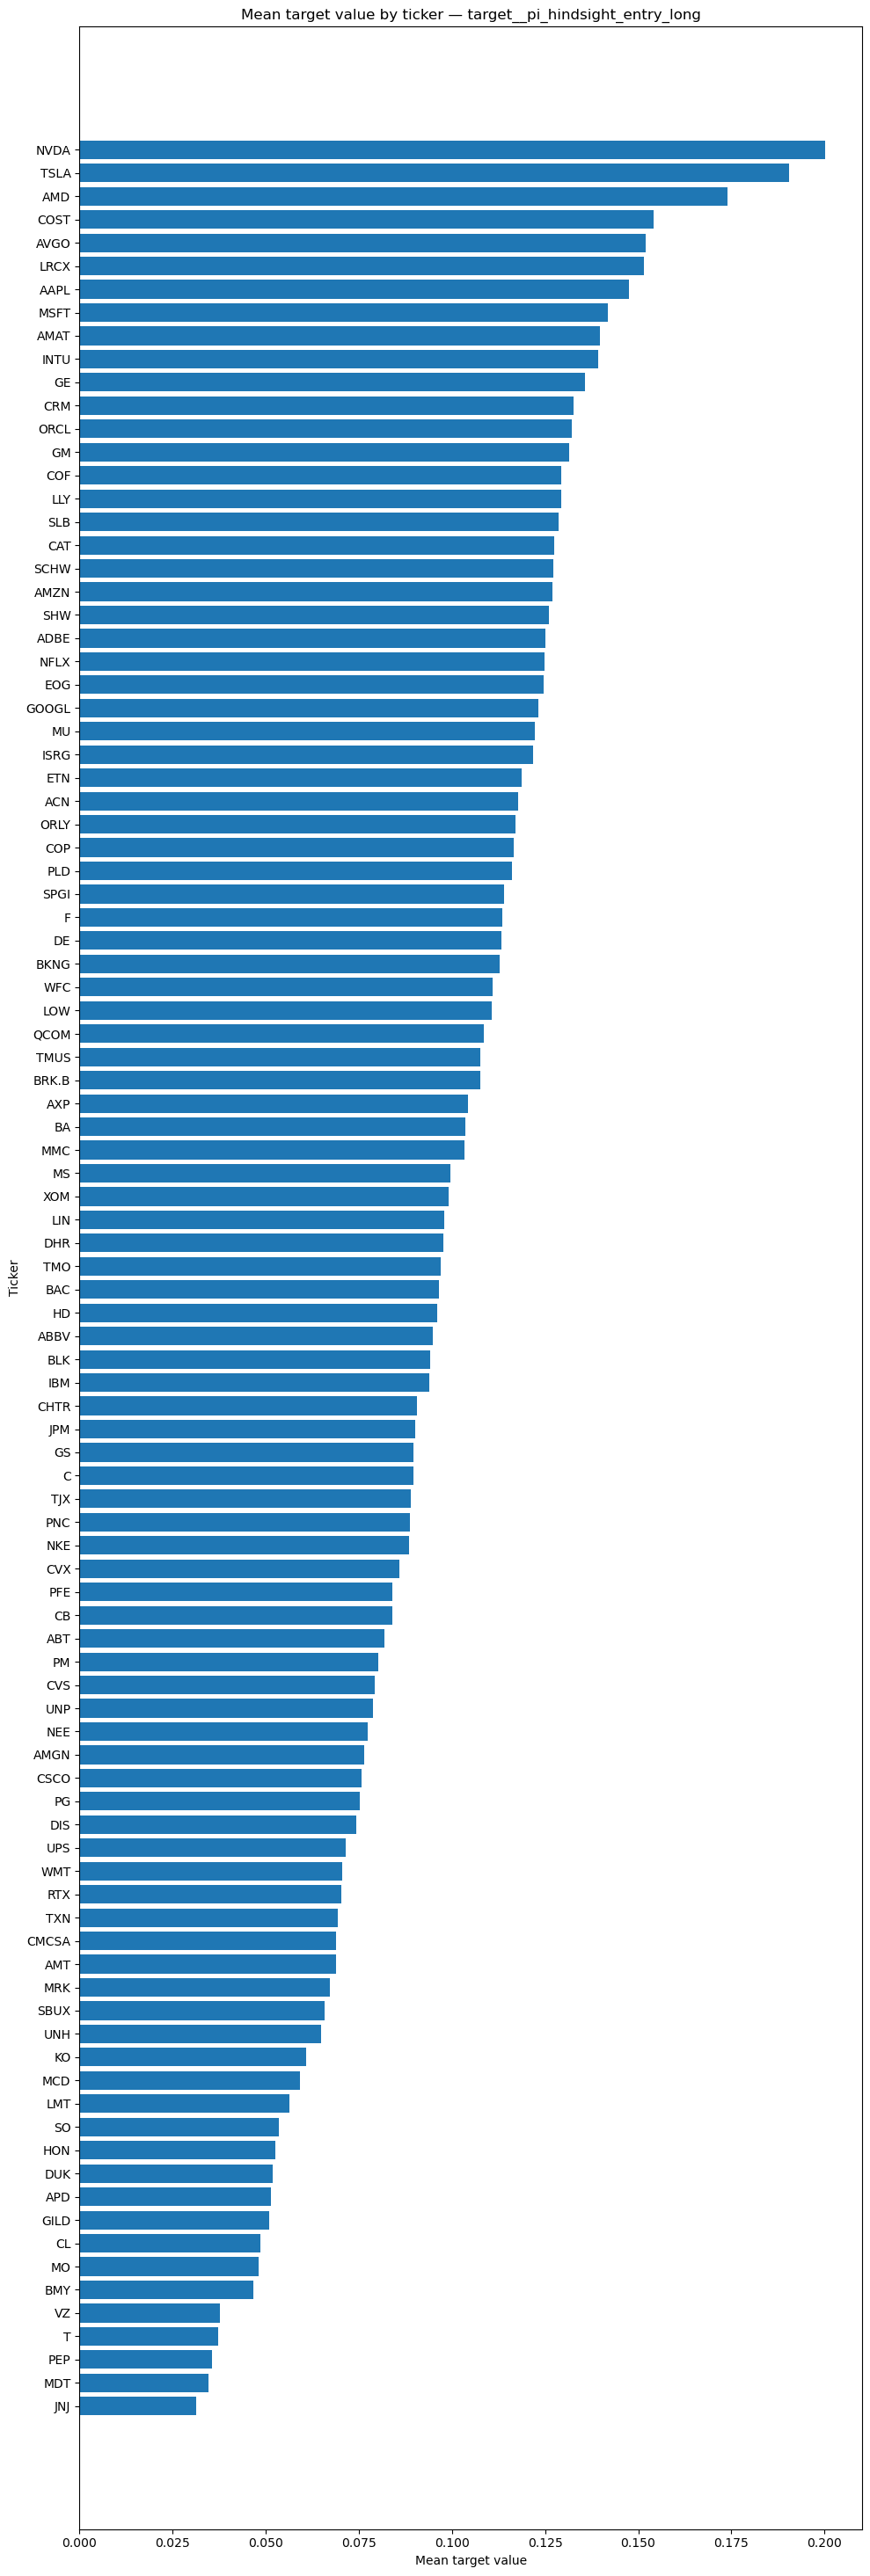

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_mean_by_ticker_target_pi_hindsight_entry_original.png


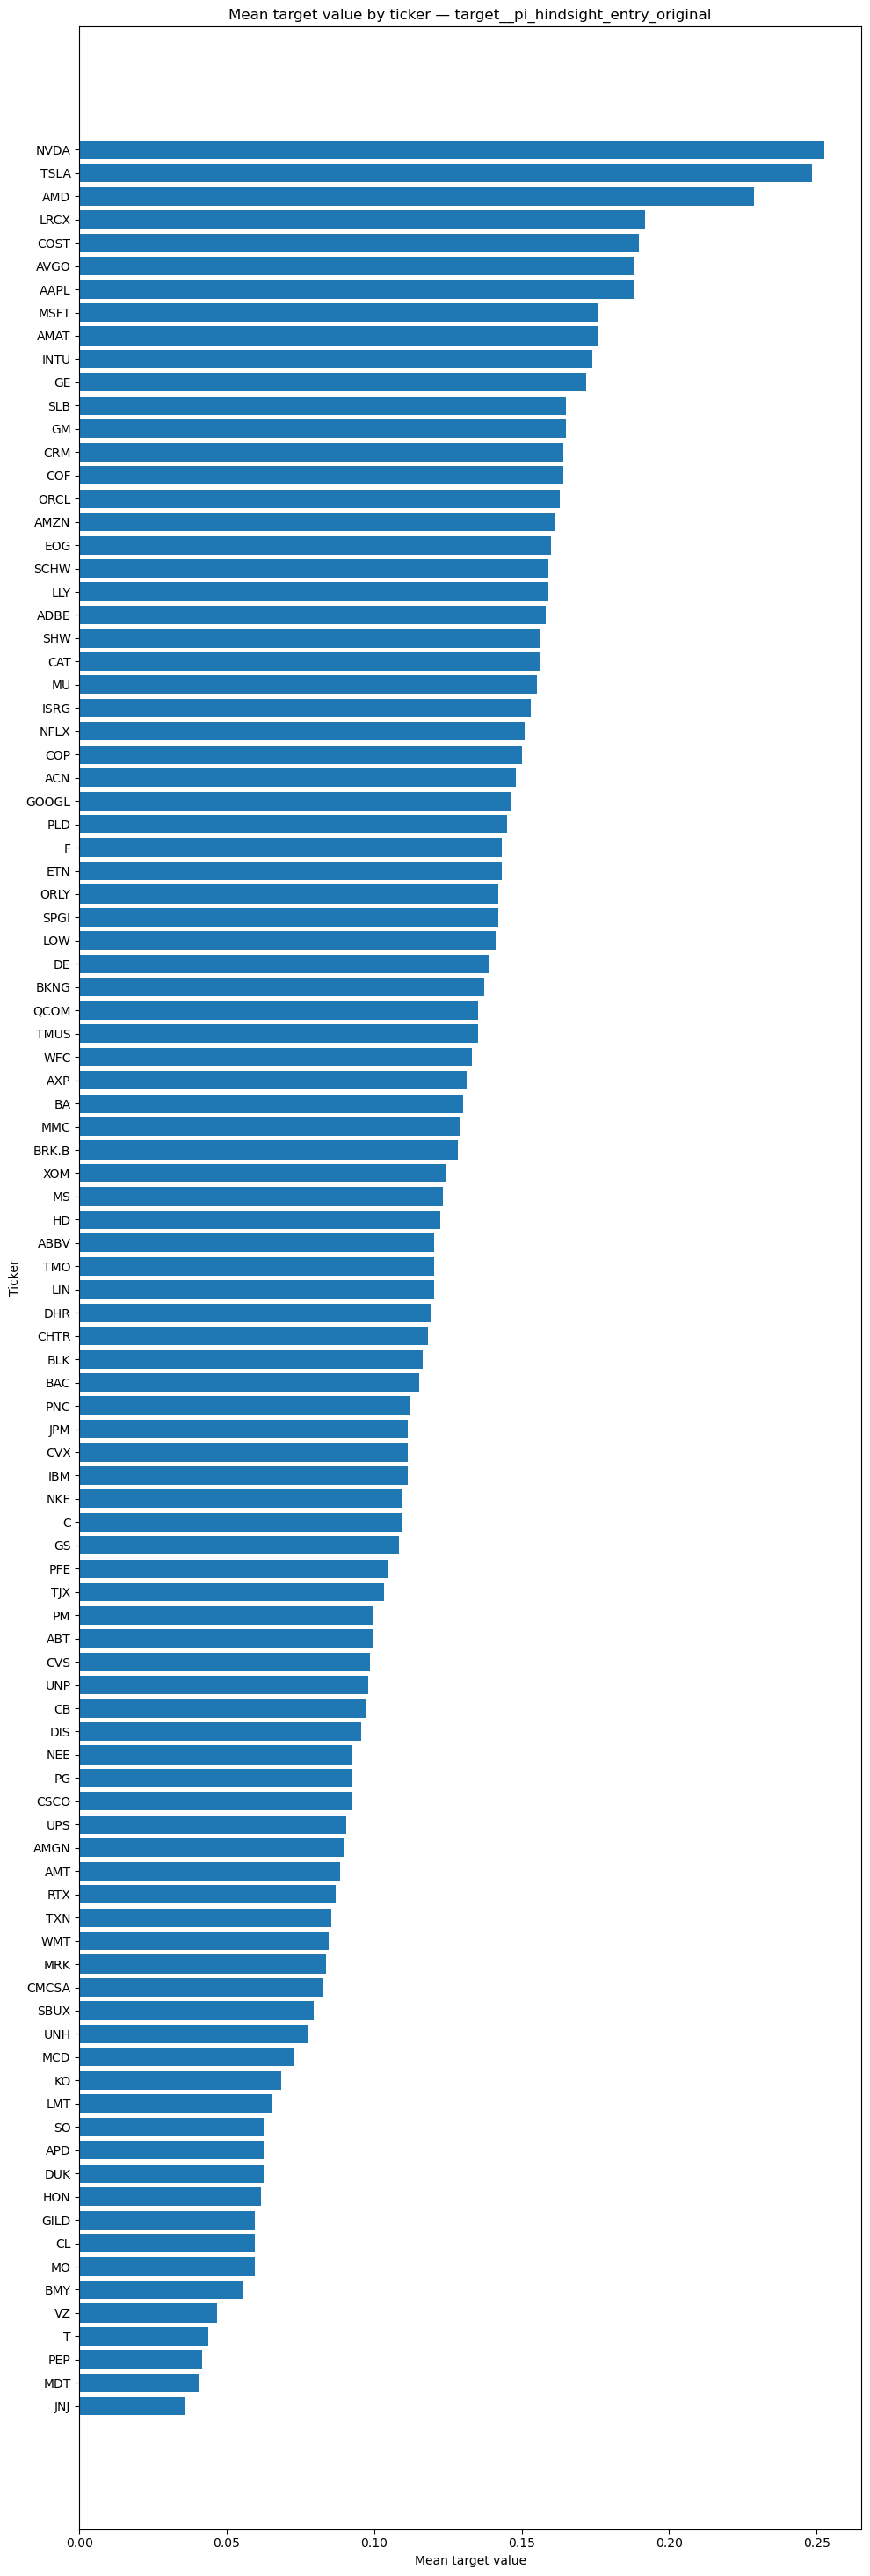

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_mean_by_ticker_target_pi_hindsight_entry_positive.png


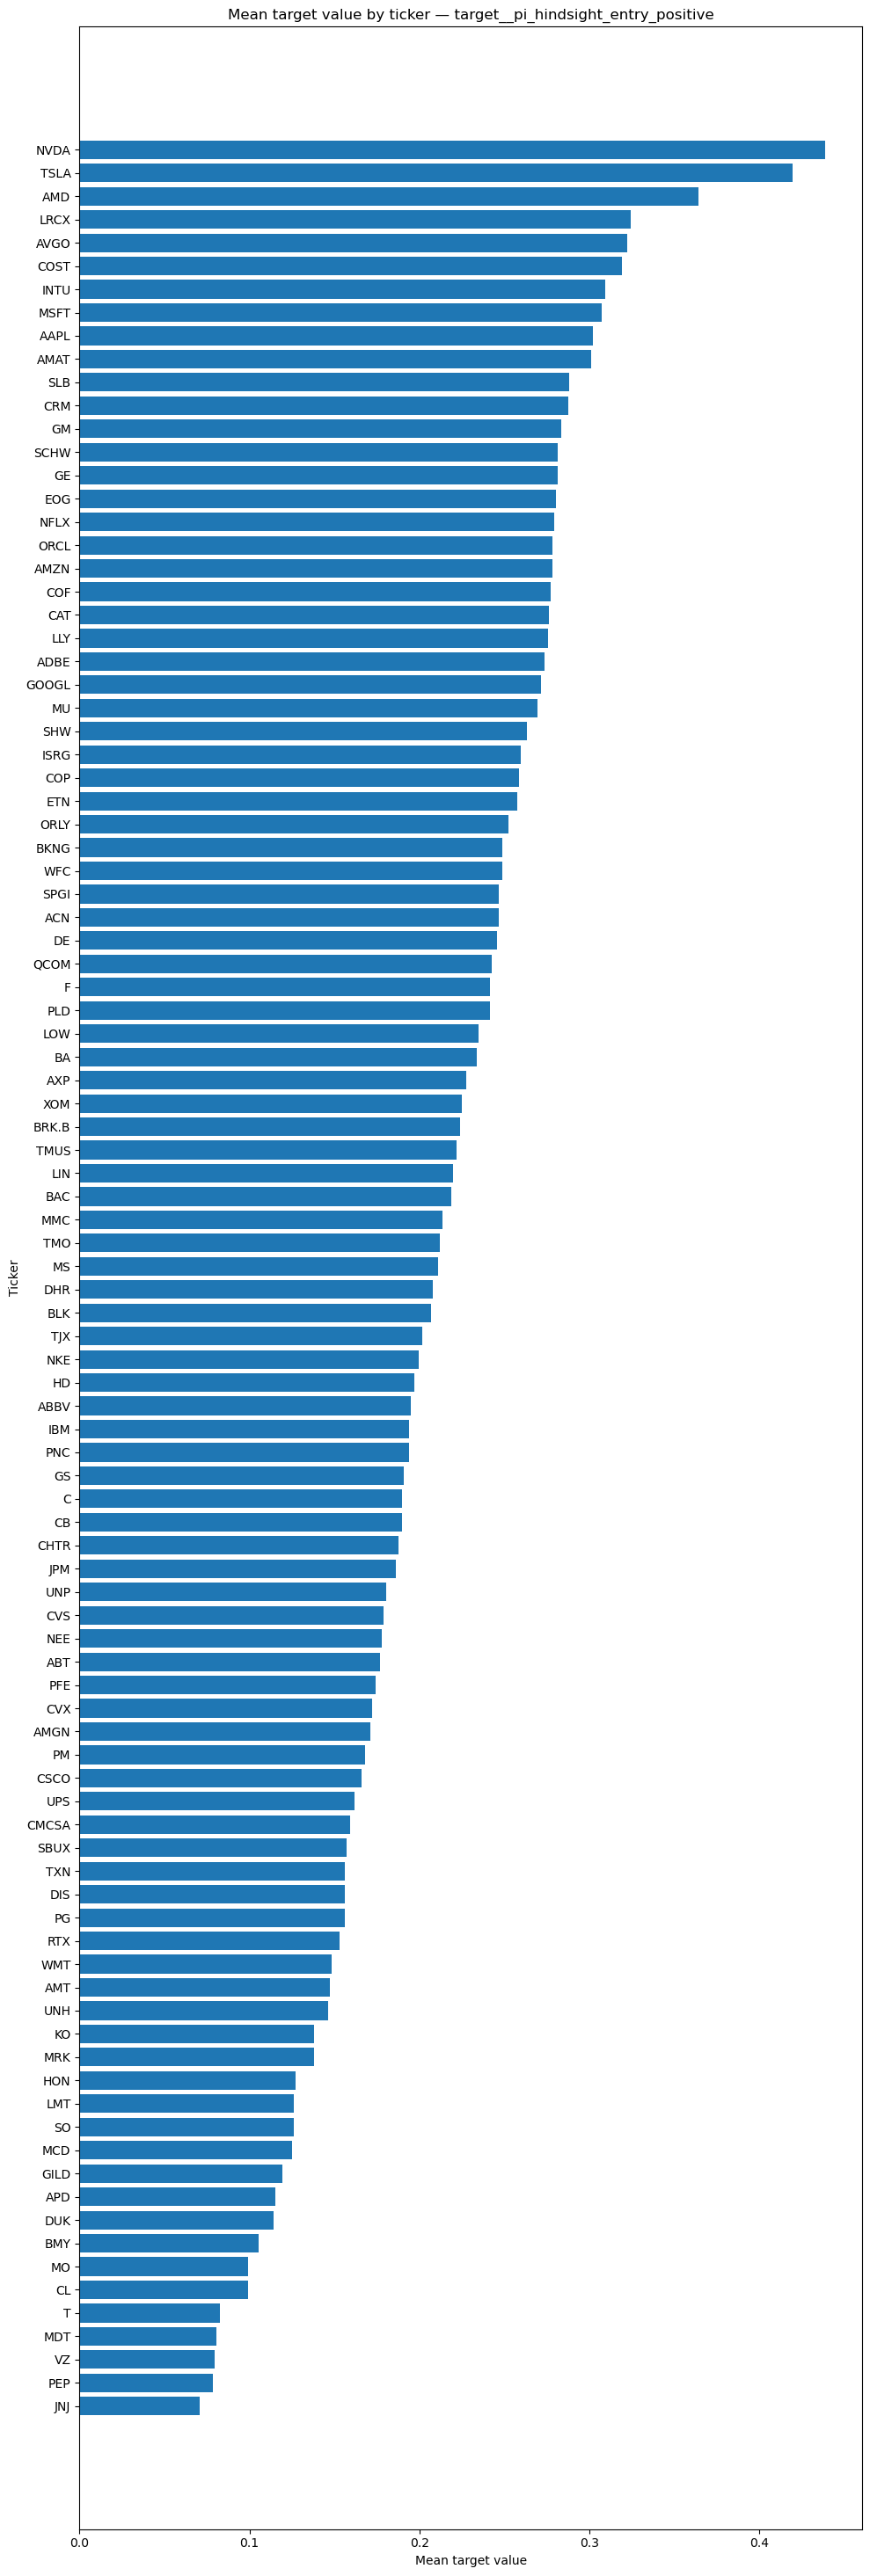

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_mean_by_ticker_target_rl_long_action_binary.png


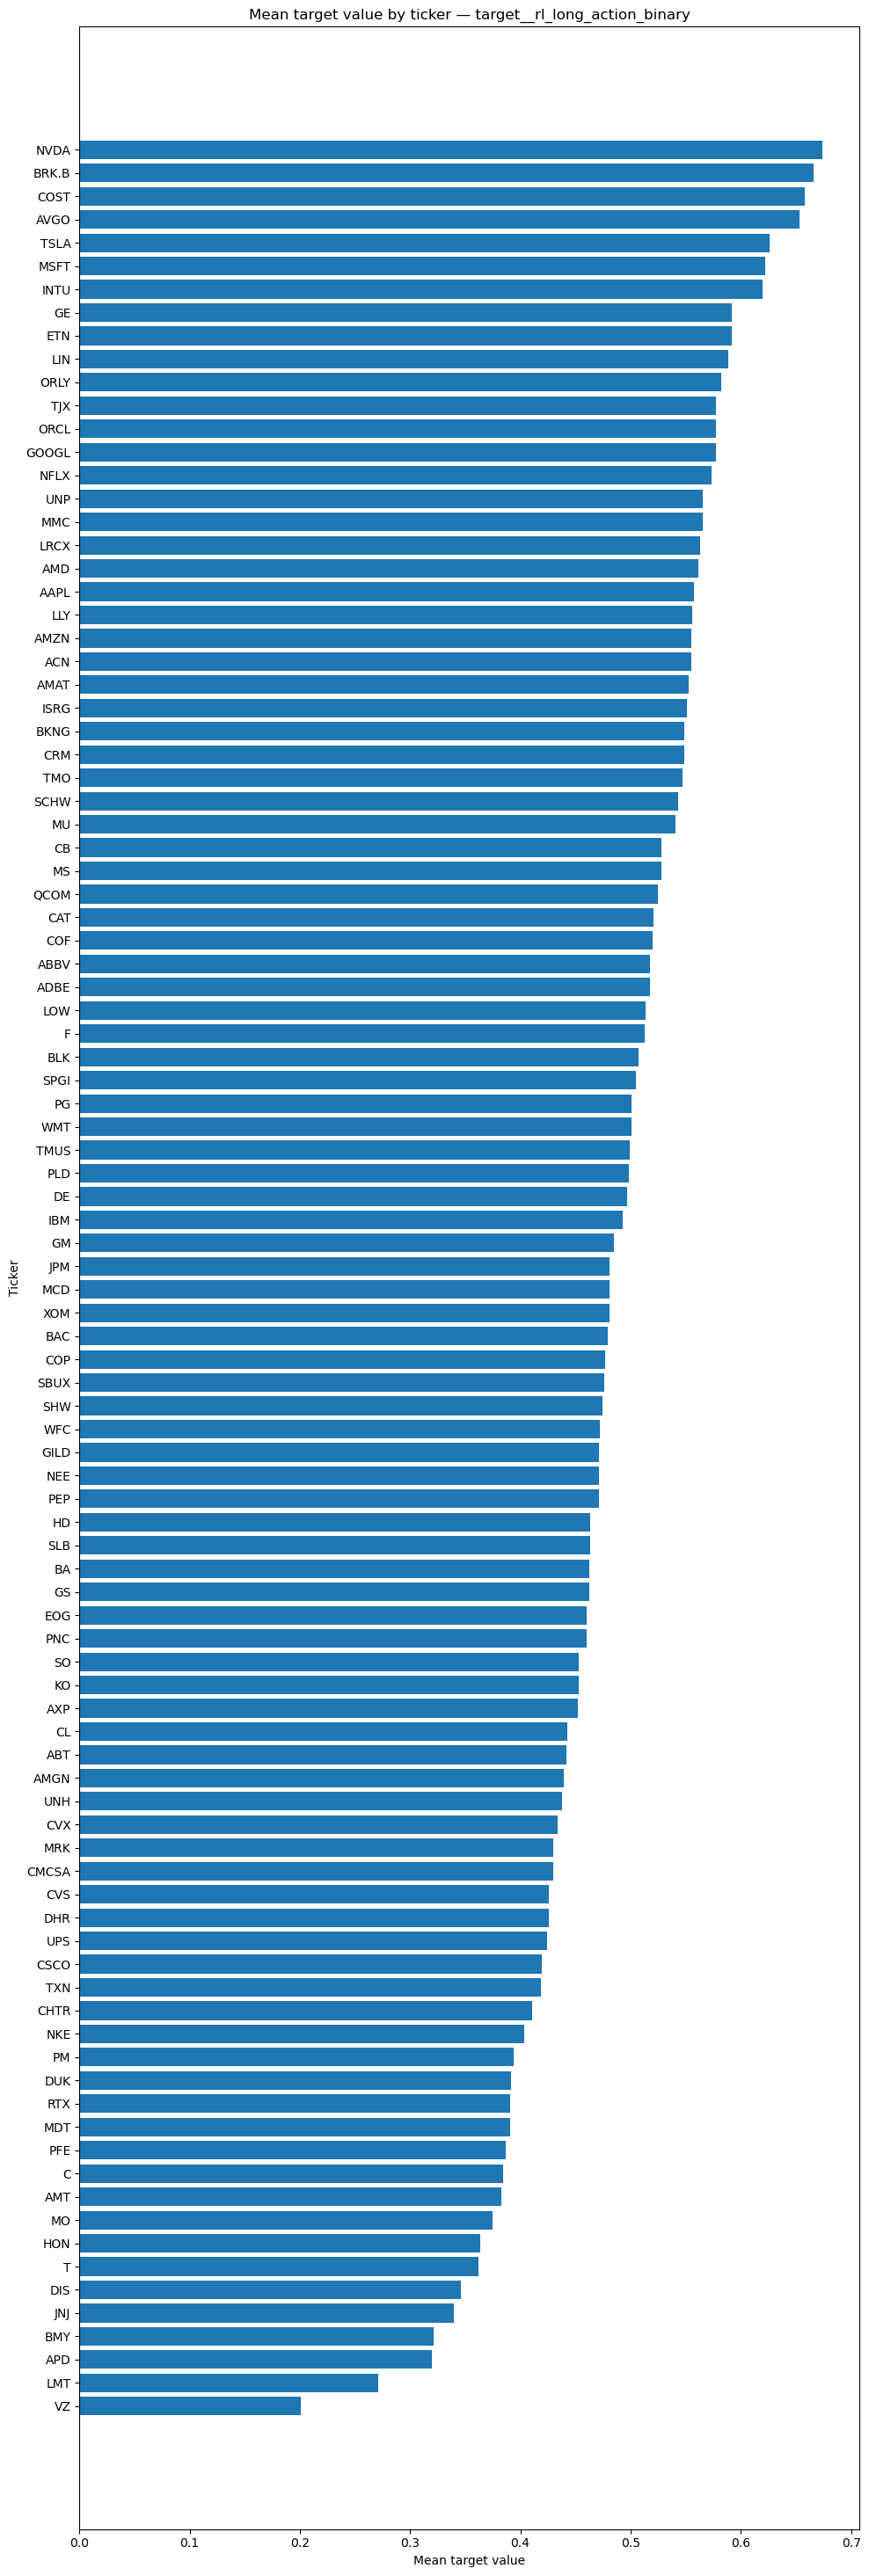

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_mean_by_ticker_target_rl_long_action_quality.png


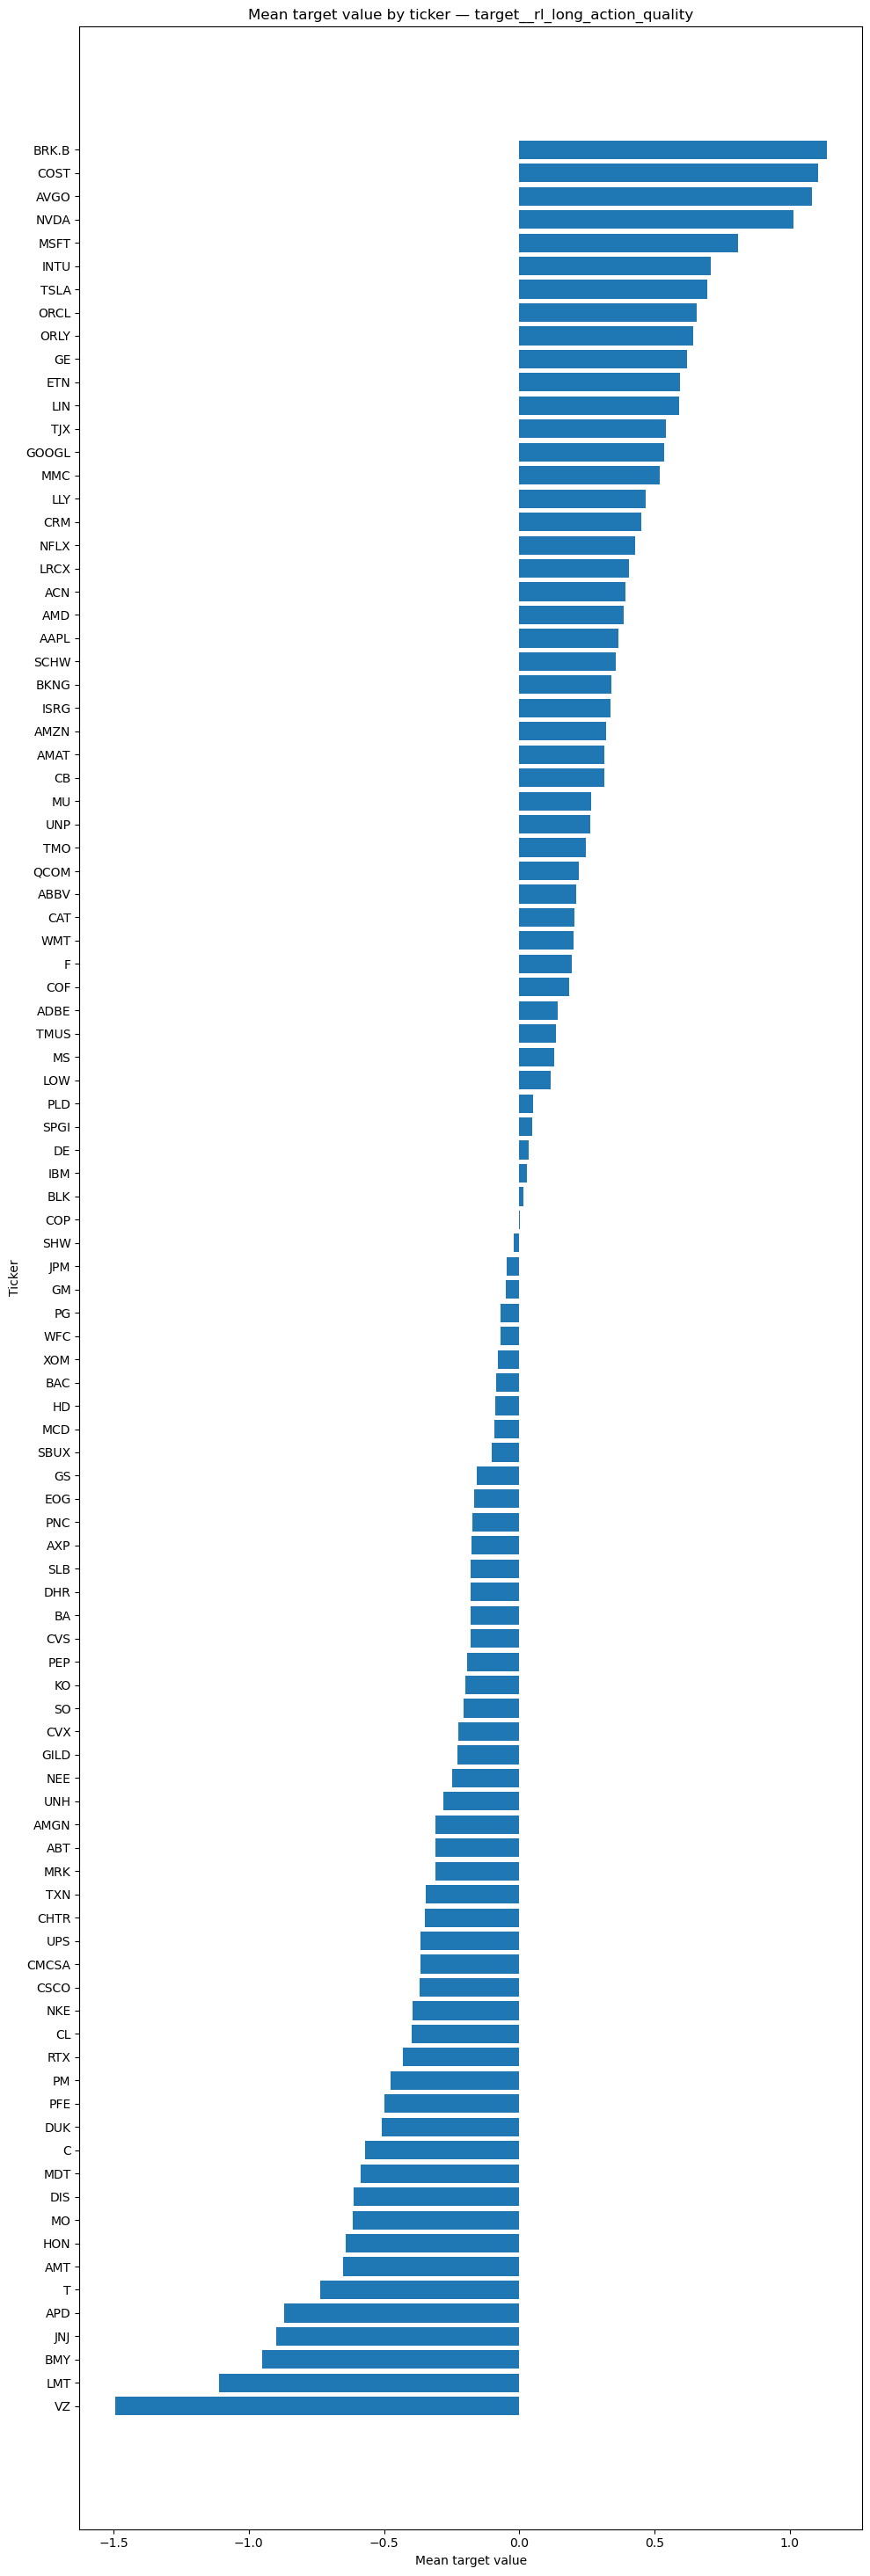

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_mean_by_ticker_target_rl_long_current_pnl.png


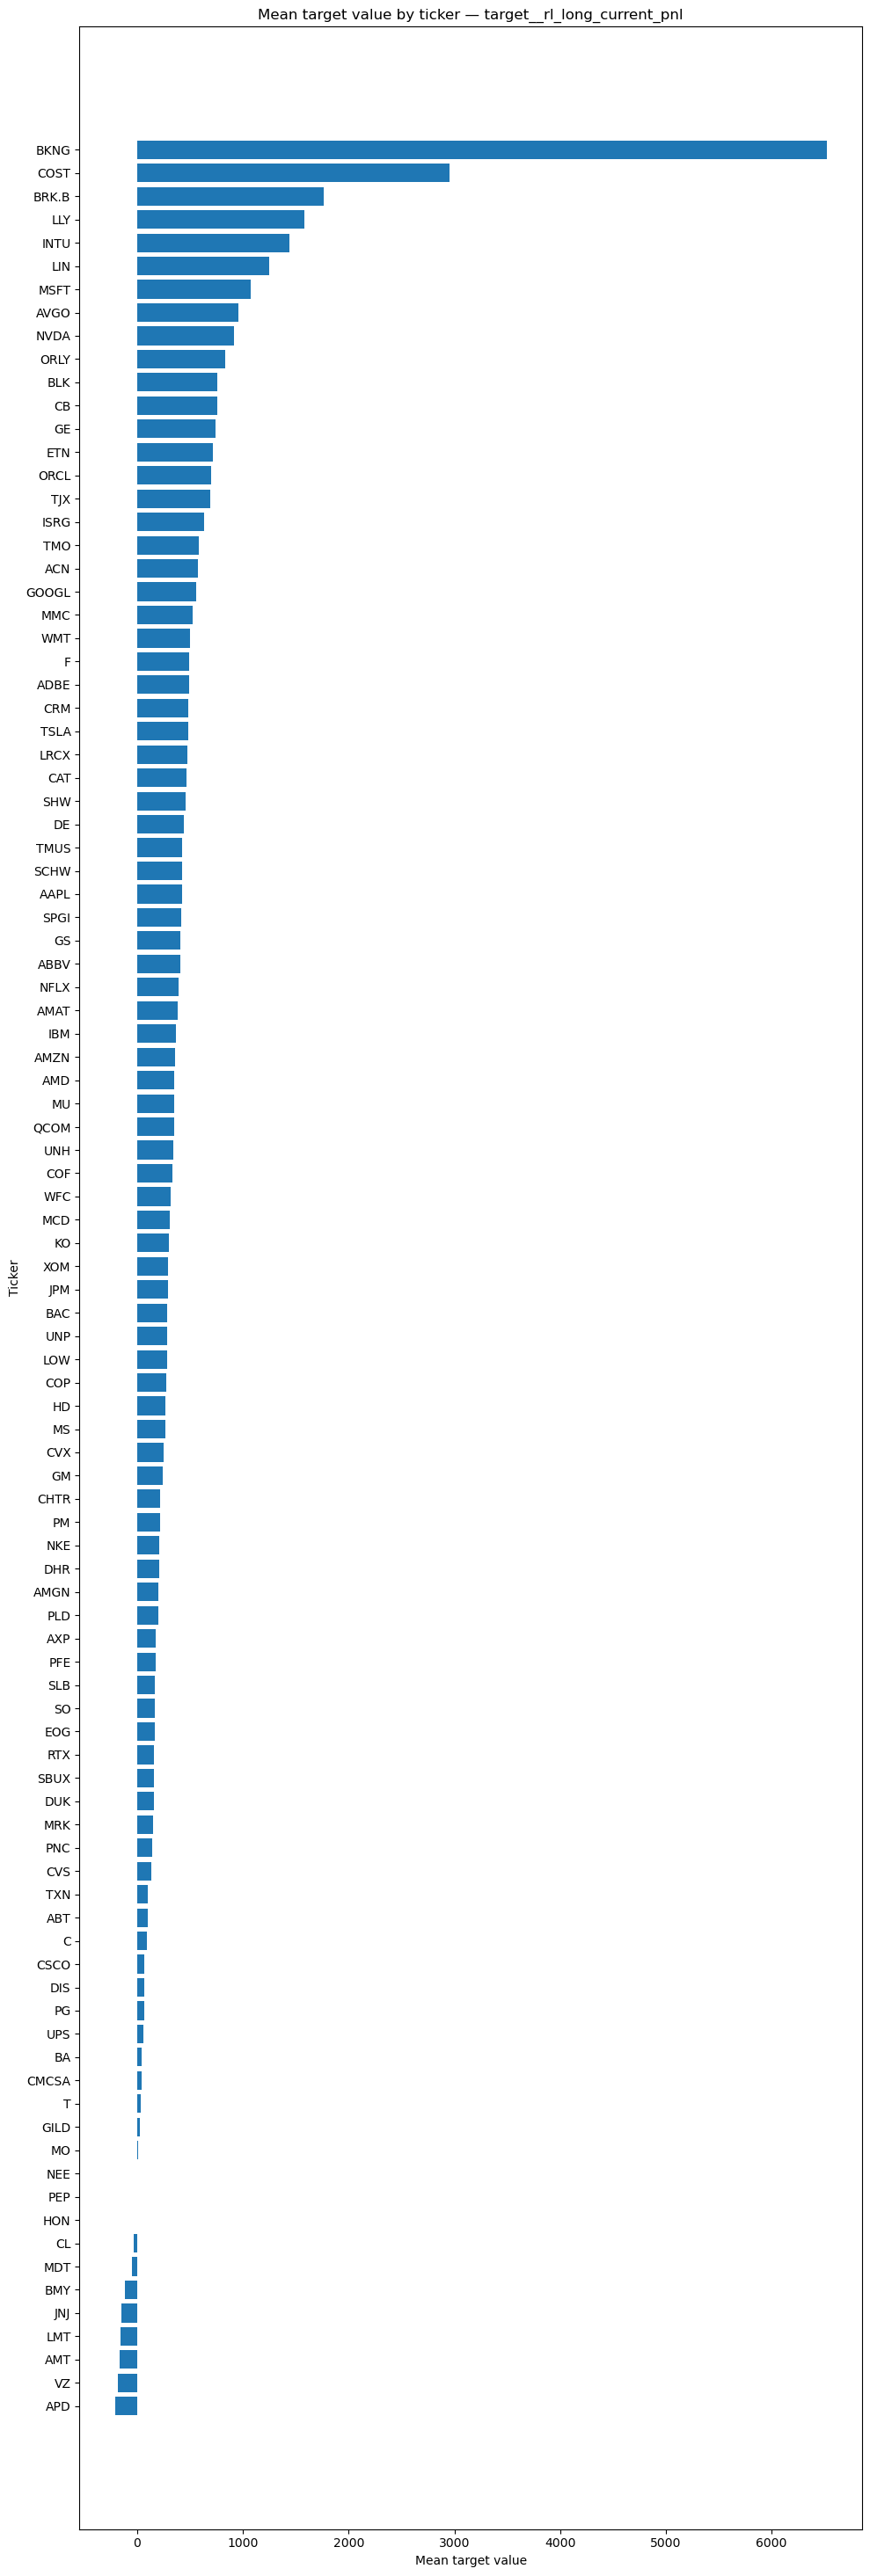

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\figures\target_mean_by_ticker_target_rl_long_reward.png


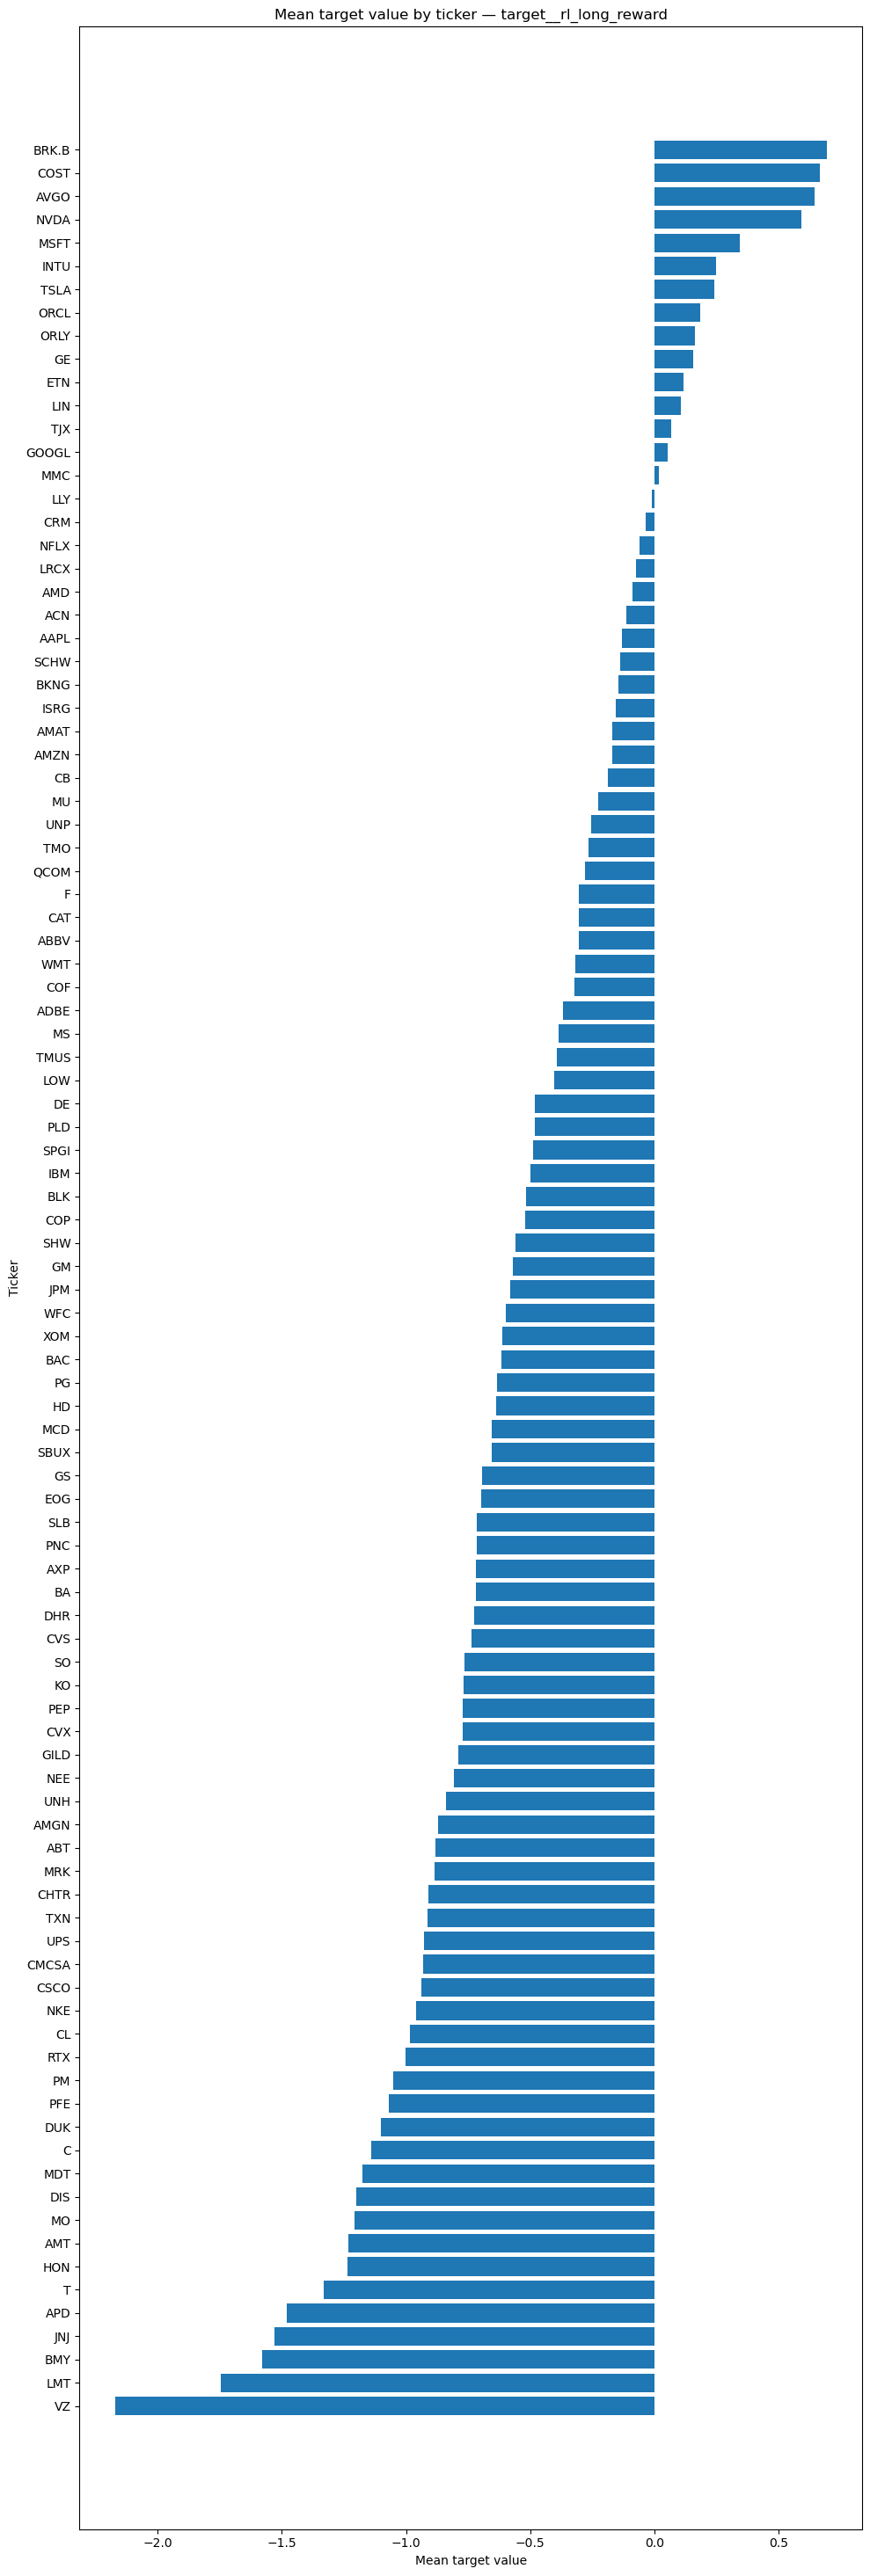

In [33]:
target_ticker_rows = []

for column in available_target_columns:
    temporary = df_train[[TICKER_COL, column]].copy()
    temporary[column] = pd.to_numeric(
        temporary[column],
        errors="coerce"
    )
    temporary = temporary.dropna(subset=[TICKER_COL, column])

    ticker_summary = (
        temporary.groupby(TICKER_COL)[column]
        .agg(
            n_obs="size",
            mean="mean",
            std="std",
            min="min",
            median="median",
            max="max"
        )
        .reset_index()
    )

    ticker_rates = (
        temporary.groupby(TICKER_COL)[column]
        .apply(
            lambda values: pd.Series({
                "zero_rate": (values == 0).mean(),
                "positive_rate": (values > 0).mean(),
                "negative_rate": (values < 0).mean()
            })
        )
        .unstack()
        .reset_index()
    )

    ticker_summary = ticker_summary.merge(
        ticker_rates,
        on=TICKER_COL,
        how="left"
    )
    ticker_summary.insert(0, "target", column)
    target_ticker_rows.append(ticker_summary)

target_by_ticker = (
    pd.concat(target_ticker_rows, ignore_index=True)
    if target_ticker_rows
    else pd.DataFrame()
)

export_table("target_summary_by_ticker", target_by_ticker)

for column in available_target_columns:
    plot_data = (
        target_by_ticker[
            target_by_ticker["target"] == column
        ]
        .sort_values("mean")
    )

    if plot_data.empty:
        continue

    plt.figure(figsize=(10, max(5, 0.3 * len(plot_data))))
    plt.barh(
        plot_data[TICKER_COL].astype(str),
        plot_data["mean"]
    )
    plt.title(f"Mean target value by ticker — {column}")
    plt.xlabel("Mean target value")
    plt.ylabel("Ticker")
    save_current_figure(f"target_mean_by_ticker_{column}")
    plt.show()


## 14. Feature–target rank correlations

In [34]:
feature_target_rows = []

correlation_features = final_feature_b_features.copy()

for target_column in available_target_columns:
    target_values = pd.to_numeric(
        df_train[target_column],
        errors="coerce"
    )

    for feature_column in correlation_features:
        feature_values = pd.to_numeric(
            df_train[feature_column],
            errors="coerce"
        )

        valid = feature_values.notna() & target_values.notna()

        if valid.sum() < 30:
            correlation = np.nan
        else:
            correlation = feature_values[valid].corr(
                target_values[valid],
                method="spearman"
            )

        feature_target_rows.append({
            "target": target_column,
            "feature": feature_column,
            "n_complete": int(valid.sum()),
            "spearman": correlation,
            "absolute_spearman": (
                abs(correlation)
                if pd.notna(correlation)
                else np.nan
            )
        })

feature_target_correlations = pd.DataFrame(feature_target_rows)

export_table(
    "feature_target_spearman_correlations",
    feature_target_correlations,
    display_table=False
)

top_feature_target_correlations = (
    feature_target_correlations
    .sort_values(
        ["target", "absolute_spearman"],
        ascending=[True, False]
    )
    .groupby("target", group_keys=False)
    .head(20)
)

export_table(
    "top_feature_target_spearman_correlations",
    top_feature_target_correlations
)


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\tables\feature_target_spearman_correlations.csv


,target,feature,n_complete,spearman,absolute_spearman
399,target__pi_hindsight_entry_6bins,feature__volatility_trailing_1m,98419,0.188698,0.188698
4,target__pi_hindsight_entry_6bins,feature__avg_daily_turnover,98419,0.122631,0.122631
380,target__pi_hindsight_entry_6bins,feature__regime_vix_percentile_1y,98419,0.112936,0.112936
365,target__pi_hindsight_entry_6bins,feature__price_vs_52w_high,98419,-0.098657,0.098657
370,target__pi_hindsight_entry_6bins,feature__regime_cpi_yoy,98419,-0.096856,0.096856
...,...,...,...,...,...
3229,target__rl_long_reward,feature__volatility_trailing_1m_vs_industry,98419,0.089461,0.089461
3063,target__rl_long_reward,feature__dividend_payout,98419,-0.089274,0.089274
2939,target__rl_long_reward,feature__b_net_debt_to_ebitda_is_below_p10,98419,0.087968,0.087968
2886,target__rl_long_reward,feature__b_days_payables_outstanding_iqr,98419,-0.085447,0.085447


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\tables\top_feature_target_spearman_correlations.csv


,target,feature,n_complete,spearman,absolute_spearman
399,target__pi_hindsight_entry_6bins,feature__volatility_trailing_1m,98419,0.188698,0.188698
4,target__pi_hindsight_entry_6bins,feature__avg_daily_turnover,98419,0.122631,0.122631
380,target__pi_hindsight_entry_6bins,feature__regime_vix_percentile_1y,98419,0.112936,0.112936
365,target__pi_hindsight_entry_6bins,feature__price_vs_52w_high,98419,-0.098657,0.098657
370,target__pi_hindsight_entry_6bins,feature__regime_cpi_yoy,98419,-0.096856,0.096856
...,...,...,...,...,...
3229,target__rl_long_reward,feature__volatility_trailing_1m_vs_industry,98419,0.089461,0.089461
3063,target__rl_long_reward,feature__dividend_payout,98419,-0.089274,0.089274
2939,target__rl_long_reward,feature__b_net_debt_to_ebitda_is_below_p10,98419,0.087968,0.087968
2886,target__rl_long_reward,feature__b_days_payables_outstanding_iqr,98419,-0.085447,0.085447


## 15. Final integrated export and manifest

In [35]:
def make_excel_safe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col in df.columns:
        # Handles normal datetime64 columns
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            try:
                df[col] = df[col].dt.tz_localize(None)
            except TypeError:
                # Already timezone-naive
                pass

        # Handles object columns containing timezone-aware Timestamp values
        elif df[col].dtype == "object":
            if df[col].map(lambda x: isinstance(x, pd.Timestamp)).any():
                df[col] = df[col].map(
                    lambda x: x.tz_localize(None)
                    if isinstance(x, pd.Timestamp) and x.tzinfo is not None
                    else x
                )

    return df

workbook_path = export_all_tables_to_workbook()

manifest = pd.DataFrame({
    "output_type": (
        ["table"] * len(list(TABLE_DIR.glob("*")))
        + ["figure"] * len(list(FIGURE_DIR.glob("*")))
        + ["inventory"] * len(list(INVENTORY_DIR.glob("*")))
    ),
    "path": (
        [str(path.resolve()) for path in sorted(TABLE_DIR.glob("*"))]
        + [str(path.resolve()) for path in sorted(FIGURE_DIR.glob("*"))]
        + [str(path.resolve()) for path in sorted(INVENTORY_DIR.glob("*"))]
    )
})

manifest.to_csv(OUTPUT_DIR / "output_manifest.csv", index=False)
display(manifest)

print("\nEDA complete.")
print("Main output directory:", OUTPUT_DIR.resolve())
print("Integrated workbook:", workbook_path.resolve())
print("Number of registered tables:", len(EXPORTED_TABLES))
print("Number of saved figures:", len(list(FIGURE_DIR.glob('*.png'))))


Saved integrated workbook: C:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\tables\recent_training_eda_all_tables.xlsx


,output_type,path
0,table,C:\Users\user\Downloads\universe_100_recent_po...
1,table,C:\Users\user\Downloads\universe_100_recent_po...
2,table,C:\Users\user\Downloads\universe_100_recent_po...
3,table,C:\Users\user\Downloads\universe_100_recent_po...
4,table,C:\Users\user\Downloads\universe_100_recent_po...
...,...,...
82,inventory,C:\Users\user\Downloads\universe_100_recent_po...
83,inventory,C:\Users\user\Downloads\universe_100_recent_po...
84,inventory,C:\Users\user\Downloads\universe_100_recent_po...
85,inventory,C:\Users\user\Downloads\universe_100_recent_po...



EDA complete.
Main output directory: C:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547
Integrated workbook: C:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment\recent_training_eda_outputs_20260716_174547\tables\recent_training_eda_all_tables.xlsx
Number of registered tables: 16
Number of saved figures: 48
